## Integrantes

Raful Habib Sánchez Morales — A01127380  
Efrén Alejandro Barroso Llanes — A01795861  
Michelle Alicia Graver Aguilar — A01242013


# Avance 3. Baseline (Modelo de Referencia)




## Índice — Baseline

18. Justificación del Algoritmo Baseline
    - 18.1 Análisis del tipo de problema
    - 18.2 Selección del algoritmo: Regresión Logística

19. Preparación de Datos para Modelado
    - 19.1 Construcción de matrices X e y
    - 19.2 División estratificada entrenamiento / prueba
    - 19.3 Balance de clases en cada partición

20. Modelo de Referencia Aleatorio (`DummyClassifier`)

21. Entrenamiento del Modelo Baseline (Regresión Logística)
    - 21.1 Entrenamiento con todas las variables (`X_todas`)
    - 21.2 Entrenamiento con variables reducidas por PCA (`X_reducida_pca`)

22. Análisis de Características Importantes
    - 22.1 Coeficientes del modelo (filter + modelo)
    - 22.2 Visualización de las características más relevantes

23. Métricas de Evaluación
    - 23.1 Justificación de métricas para clases desbalanceadas
    - 23.2 Reporte de clasificación
    - 23.3 Matriz de confusión
    - 23.4 Curva ROC-AUC

24. Análisis de Sub/Sobreajuste
    - 24.1 Comparación de métricas entrenamiento vs prueba
    - 24.2 Curvas de aprendizaje
    - 24.3 Validación cruzada estratificada (k-fold)

25. Desempeño Mínimo Aceptable
    - 25.1 Definición del umbral histórico
    - 25.2 Comparación con referencias de la literatura
    - 25.3 Verificación del modelo baseline

26. Conclusiones CRISP-ML — Fase de Modelado (Baseline)

In [ ]:
# ── Importaciones adicionales para la sección Baseline ──────────────
from sklearn.dummy          import DummyClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, learning_curve)
from sklearn.metrics        import (classification_report, confusion_matrix,
                                    ConfusionMatrixDisplay,
                                    roc_auc_score, roc_curve,
                                    balanced_accuracy_score, f1_score,
                                    precision_score, recall_score,
                                    average_precision_score,
                                    PrecisionRecallDisplay)
from sklearn.pipeline       import Pipeline
import warnings
warnings.filterwarnings('ignore')

print('Librerías de modelado cargadas correctamente.')

Librerías de modelado cargadas correctamente.


---
## 18. Justificación del Algoritmo Baseline

### 18.1 Análisis del Tipo de Problema

| Dimensión | Característica del problema |
|---|---|
| **Tipo de datos** | Estructurados — tabla con variables de expresión génica (numéricas) y clínicas (categóricas) |
| **Tipo de tarea** | Clasificación binaria supervisada: Psoriasis (`1`) vs. Control sano (`0`) |
| **Tamaño del dataset** | Pocas muestras (docenas/centenas de pacientes), muchas características (cientos de sondas genómicas) → régimen *p >> n* |
| **Balance de clases** | Potencialmente desbalanceado (evaluado en sección 19) |
| **Interpretabilidad** | Alta: importa saber qué genes/variables clínicas discriminan la condición |
| **Línea base de referencia** | Clasificador aleatorio estratificado (DummyClassifier) |

### 18.2 Selección del Algoritmo: Regresión Logística

**Justificación frente a las alternativas:**

| Algoritmo | Pros | Contras para este caso |
|---|---|---|
| **Regresión Logística** ✅ | Simple, interpretable, coeficientes = importancia, funciona bien con regularización en *p >> n* | Asume linealidad; requiere escalado |
| Árbol de Decisión | Interpretable, no requiere escalado | Propenso a sobreajuste; no es un buen *baseline* |
| KNN | No paramétrico | Muy sensible a la dimensionalidad (*curse of dimensionality*) |
| SVM lineal | Bueno en *p >> n* | Menos interpretable; coeficientes no son probabilidades |
| Red neuronal | Alta capacidad | Requiere muchos datos; no apropiada como baseline |

La **Regresión Logística con regularización L2** (Ridge) es el baseline estándar para clasificación binaria con datos estructurados de alta dimensionalidad. Permite:
- Obtener probabilidades calibradas.
- Interpretar los coeficientes como importancia de características.
- Controlar el sobreajuste mediante el parámetro `C`.
- Manejar clases desbalanceadas con `class_weight='balanced'`.

---
## 19. Preparación de Datos para Modelado

### 19.1 Construcción de Matrices X e y

In [ ]:
# Las matrices X_todas, X_reducida_pca, X_reducida_fa y y fueron construidas en la sección FE.
# Verificamos que estén disponibles y reseteamos índices para consistencia.

assert 'X_todas'        in dir() or 'X_todas'        in locals(), 'Ejecutar primero la sección FE (Sección 14)'
assert 'X_reducida_pca' in dir() or 'X_reducida_pca' in locals(), 'Ejecutar primero la sección FE (Sección 15)'
assert 'y'              in dir() or 'y'              in locals(), 'Ejecutar primero la sección FE (target y)'

# Reset de índices para alinear correctamente con sklearn
X_todas_bl        = X_todas.reset_index(drop=True)
X_pca_bl          = X_reducida_pca.reset_index(drop=True)
y_bl              = y.reset_index(drop=True)

print('=== Matrices disponibles para modelado ===')
print(f'  X_todas        : {X_todas_bl.shape}')
print(f'  X_reducida_pca : {X_pca_bl.shape}')
print(f'  y (target)     : {y_bl.shape}  — clases: {dict(y_bl.value_counts())}')

=== Matrices disponibles para modelado ===
  X_todas        : (645, 210)
  X_reducida_pca : (645, 67)
  y (target)     : (645,)  — clases: {1: np.int64(423), 0: np.int64(222)}


### 19.2 División Estratificada Entrenamiento / Prueba

Se utiliza `stratify=y` para mantener la proporción de clases en ambas particiones. Una división 80/20 es estándar para datasets de tamaño moderado.

In [ ]:
TEST_SIZE   = 0.20
RANDOM_SEED = 42

# División para X_todas
X_train_t, X_test_t, y_train, y_test = train_test_split(
    X_todas_bl, y_bl, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_bl
)

# División para X_pca (mismos índices → mismos registros)
X_train_p = X_pca_bl.loc[X_train_t.index]
X_test_p  = X_pca_bl.loc[X_test_t.index]

print(f'Tamaño de entrenamiento : {X_train_t.shape[0]} muestras')
print(f'Tamaño de prueba        : {X_test_t.shape[0]} muestras')
print(f'\nDistribución de clases en entrenamiento:')
print(y_train.value_counts())
print(f'\nDistribución de clases en prueba:')
print(y_test.value_counts())

Tamaño de entrenamiento : 516 muestras
Tamaño de prueba        : 129 muestras

Distribución de clases en entrenamiento:
Condition/control
1    338
0    178
Name: count, dtype: int64

Distribución de clases en prueba:
Condition/control
1    85
0    44
Name: count, dtype: int64


In [ ]:
# ── 19.2b Aplicación de SMOTE al conjunto de entrenamiento ──────────────────
# SMOTE se aplica ÚNICAMENTE sobre el conjunto de entrenamiento para evitar
# data leakage. El conjunto de prueba permanece con la distribución original.

ratio_raw = y_train.value_counts().max() / y_train.value_counts().min()
print(f'Ratio de desbalance ANTES de SMOTE: {ratio_raw:.2f}:1')
print(f'Clases en entrenamiento: {dict(y_train.value_counts())}')

smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)

# X_todas (datos completos escalados)
X_train_sm, y_train_sm = smote.fit_resample(X_train_t, y_train)

# X_pca (representación reducida)
X_train_p_sm, _ = smote.fit_resample(X_train_p, y_train)

print(f'\nDistribución DESPUÉS de SMOTE:')
print(f'  Clases: {dict(pd.Series(y_train_sm).value_counts())}')
print(f'  Muestras totales en entrenamiento: {X_train_sm.shape[0]}  '
      f'(antes: {X_train_t.shape[0]})')
print(f'\nNota: el conjunto de prueba NO se modifica ({X_test_t.shape[0]} muestras).')

Ratio de desbalance ANTES de SMOTE: 1.90:1
Clases en entrenamiento: {1: np.int64(338), 0: np.int64(178)}

Distribución DESPUÉS de SMOTE:
  Clases: {1: np.int64(338), 0: np.int64(338)}
  Muestras totales en entrenamiento: 676  (antes: 516)

Nota: el conjunto de prueba NO se modifica (129 muestras).


### 19.3 Balance de Clases en Cada Partición

Ratio de desbalance original      : 1.90:1
Ratio de desbalance post-SMOTE    : 1.00:1  (objetivo: 1.00:1)
→ SMOTE aplicado: clases balanceadas para el entrenamiento.


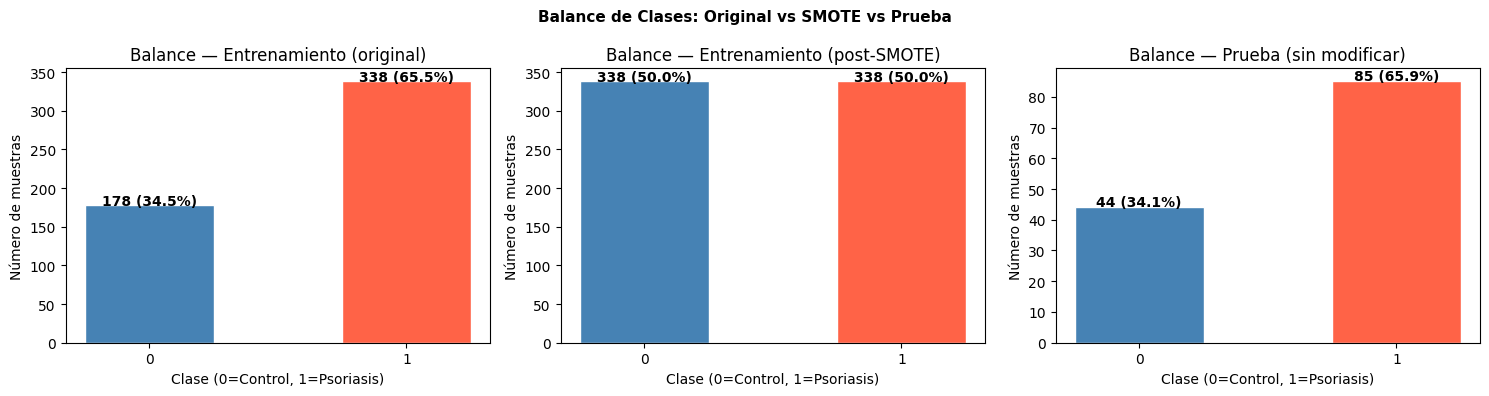

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, y_part) in zip(axes, [
    ('Entrenamiento (original)',    y_train),
    ('Entrenamiento (post-SMOTE)', pd.Series(y_train_sm)),
    ('Prueba (sin modificar)',     y_test),
]):
    conteo = pd.Series(y_part).value_counts().sort_index()
    colores_clase = ['steelblue' if c == 0 else 'tomato' for c in conteo.index]
    ax.bar([str(c) for c in conteo.index], conteo.values,
           color=colores_clase, edgecolor='white', width=0.5)
    for i, (v, p) in enumerate(zip(conteo.values, (conteo / conteo.sum() * 100).values)):
        ax.text(i, v + 0.5, f'{v} ({p:.1f}%)', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'Balance — {nombre}')
    ax.set_xlabel('Clase (0=Control, 1=Psoriasis)')
    ax.set_ylabel('Número de muestras')

ratio_train = y_train.value_counts().max() / y_train.value_counts().min()
ratio_sm    = pd.Series(y_train_sm).value_counts().max() / pd.Series(y_train_sm).value_counts().min()
print(f'Ratio de desbalance original      : {ratio_train:.2f}:1')
print(f'Ratio de desbalance post-SMOTE    : {ratio_sm:.2f}:1  (objetivo: 1.00:1)')
print(f'→ SMOTE aplicado: clases balanceadas para el entrenamiento.')

plt.suptitle('Balance de Clases: Original vs SMOTE vs Prueba', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 20. Modelo de Referencia Aleatorio — `DummyClassifier`

**Propósito:** El `DummyClassifier` con estrategia `stratified` genera predicciones respetando la distribución de clases del conjunto de entrenamiento, sin aprender ningún patrón. Representa el **piso mínimo absoluto** de desempeño: cualquier modelo real debe superarlo significativamente para considerarse útil.

In [ ]:
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)
dummy.fit(X_train_t, y_train)

y_pred_dummy = dummy.predict(X_test_t)
y_prob_dummy = dummy.predict_proba(X_test_t)[:, 1]

auc_dummy       = roc_auc_score(y_test, y_prob_dummy)
f1_dummy        = f1_score(y_test, y_pred_dummy, average='weighted')
bal_acc_dummy   = balanced_accuracy_score(y_test, y_pred_dummy)

print('=== DummyClassifier (Referencia Aleatoria) ===')
print(f'  AUC-ROC           : {auc_dummy:.4f}')
print(f'  F1-score (weighted): {f1_dummy:.4f}')
print(f'  Balanced Accuracy  : {bal_acc_dummy:.4f}')
print('\n  → Estos valores representan el PISO MÍNIMO que debe superar el modelo baseline.')

=== DummyClassifier (Referencia Aleatoria) ===
  AUC-ROC           : 0.5230
  F1-score (weighted): 0.5724
  Balanced Accuracy  : 0.5230

  → Estos valores representan el PISO MÍNIMO que debe superar el modelo baseline.


---
## 21. Entrenamiento del Modelo Baseline — Regresión Logística

### 21.1 Entrenamiento con Todas las Variables (`X_todas`)

Se entrena con `class_weight='balanced'` para compensar cualquier desbalance de clases. La regularización L2 (`C=1.0`) evita el sobreajuste en el régimen de alta dimensionalidad.

In [ ]:
lr_todas = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    random_state=RANDOM_SEED
)
lr_todas.fit(X_train_sm, y_train_sm)

# Predicciones sobre entrenamiento y prueba
y_pred_todas_train = lr_todas.predict(X_train_sm)
y_pred_todas_test  = lr_todas.predict(X_test_t)
y_prob_todas_test  = lr_todas.predict_proba(X_test_t)[:, 1]

print('=== Regresión Logística — X_todas (entrenada con SMOTE) ===')
print(f'  AUC-ROC (test)            : {roc_auc_score(y_test, y_prob_todas_test):.4f}')
print(f'  F1-score weighted (test)  : {f1_score(y_test, y_pred_todas_test, average="weighted"):.4f}')
print(f'  Balanced Accuracy (test)  : {balanced_accuracy_score(y_test, y_pred_todas_test):.4f}')
print(f'\n  AUC-ROC (train SMOTE)     : {roc_auc_score(y_train_sm, lr_todas.predict_proba(X_train_sm)[:,1]):.4f}')
print(f'  Balanced Accuracy (train) : {balanced_accuracy_score(y_train_sm, y_pred_todas_train):.4f}')

=== Regresión Logística — X_todas (entrenada con SMOTE) ===
  AUC-ROC (test)            : 0.9922
  F1-score weighted (test)  : 0.9846
  Balanced Accuracy (test)  : 0.9882

  AUC-ROC (train SMOTE)     : 1.0000
  Balanced Accuracy (train) : 0.9956


### 21.2 Entrenamiento con Variables Reducidas por PCA (`X_reducida_pca`)

In [ ]:
lr_pca = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    random_state=RANDOM_SEED
)
lr_pca.fit(X_train_p_sm, y_train_sm)

y_pred_pca_train = lr_pca.predict(X_train_p_sm)
y_pred_pca_test  = lr_pca.predict(X_test_p)
y_prob_pca_test  = lr_pca.predict_proba(X_test_p)[:, 1]

print('=== Regresión Logística — X_reducida_pca (entrenada con SMOTE) ===')
print(f'  AUC-ROC (test)            : {roc_auc_score(y_test, y_prob_pca_test):.4f}')
print(f'  F1-score weighted (test)  : {f1_score(y_test, y_pred_pca_test, average="weighted"):.4f}')
print(f'  Balanced Accuracy (test)  : {balanced_accuracy_score(y_test, y_pred_pca_test):.4f}')
print(f'\n  AUC-ROC (train SMOTE)     : {roc_auc_score(y_train_sm, lr_pca.predict_proba(X_train_p_sm)[:,1]):.4f}')
print(f'  Balanced Accuracy (train) : {balanced_accuracy_score(y_train_sm, y_pred_pca_train):.4f}')

# Comparación rápida ambos modelos
print('\n=== Comparación de Matrices ===')
print(f'{"Matriz":<25} {"AUC-ROC":>10} {"F1-weighted":>12} {"Bal.Acc":>10}')
print('-' * 58)
for nombre, y_pred_t, y_prob_e in [
    ('X_todas',        y_pred_todas_test, y_prob_todas_test),
    ('X_reducida_pca', y_pred_pca_test,  y_prob_pca_test),
]:
    auc  = roc_auc_score(y_test, y_prob_e)
    f1   = f1_score(y_test, y_pred_t, average='weighted')
    bacc = balanced_accuracy_score(y_test, y_pred_t)
    print(f'{nombre:<25} {auc:>10.4f} {f1:>12.4f} {bacc:>10.4f}')

=== Regresión Logística — X_reducida_pca (entrenada con SMOTE) ===
  AUC-ROC (test)            : 0.9813
  F1-score weighted (test)  : 0.9466
  Balanced Accuracy (test)  : 0.9588

  AUC-ROC (train SMOTE)     : 0.9979
  Balanced Accuracy (train) : 0.9660

=== Comparación de Matrices ===
Matriz                       AUC-ROC  F1-weighted    Bal.Acc
----------------------------------------------------------
X_todas                       0.9922       0.9846     0.9882
X_reducida_pca                0.9813       0.9466     0.9588


---
## 22. Análisis de Características Importantes

### 22.1 Coeficientes del Modelo — Métodos Filter + Modelo

Los coeficientes de la regresión logística (después del escalamiento) son proporcionales a la importancia de cada característica: un coeficiente positivo grande indica que la variable favorece la clase *Psoriasis*; negativo, la clase *Control*.

Se combinan tres perspectivas:
1. **Filter** (MI Score de la sección 11.3 del FE)
2. **Wrapper/Embedding** (coeficientes de la regresión logística sobre `X_todas`)

In [ ]:
coef_series = pd.Series(
    lr_todas.coef_[0],
    index=X_todas_bl.columns
).sort_values(key=abs, ascending=False)

coef_df = pd.DataFrame({
    'Variable':    coef_series.index,
    'Coeficiente': coef_series.values,
    '|Coef|':      coef_series.abs().values,
    'Dirección':   ['→ Psoriasis' if c > 0 else '→ Control' for c in coef_series.values]
})

print('Top 20 características más importantes (Regresión Logística — X_todas):')
display(coef_df.head(20))

Top 20 características más importantes (Regresión Logística — X_todas):


,Variable,Coeficiente,|Coef|,Dirección
0,STAT1 AFFX-HUMISGF3A/M97935_5_at,2.069662,2.069662,→ Psoriasis
1,Age_21-69,1.750245,1.750245,→ Psoriasis
2,Age_18-75,-1.726423,1.726423,→ Control
3,IL6 205207_at,-1.295628,1.295628,→ Control
4,RORC 228806_at,-1.248472,1.248472,→ Control
5,TNF 207113_s_at,-1.091198,1.091198,→ Control
6,CD86 205686_s_at,-1.050769,1.050769,→ Control
7,SPRR2G 236119_s_at,1.010515,1.010515,→ Psoriasis
8,RNASE7 233488_at,0.963994,0.963994,→ Psoriasis
9,PTGS2 204748_at,-0.918707,0.918707,→ Control


### 22.2 Visualización de las Características Más Relevantes

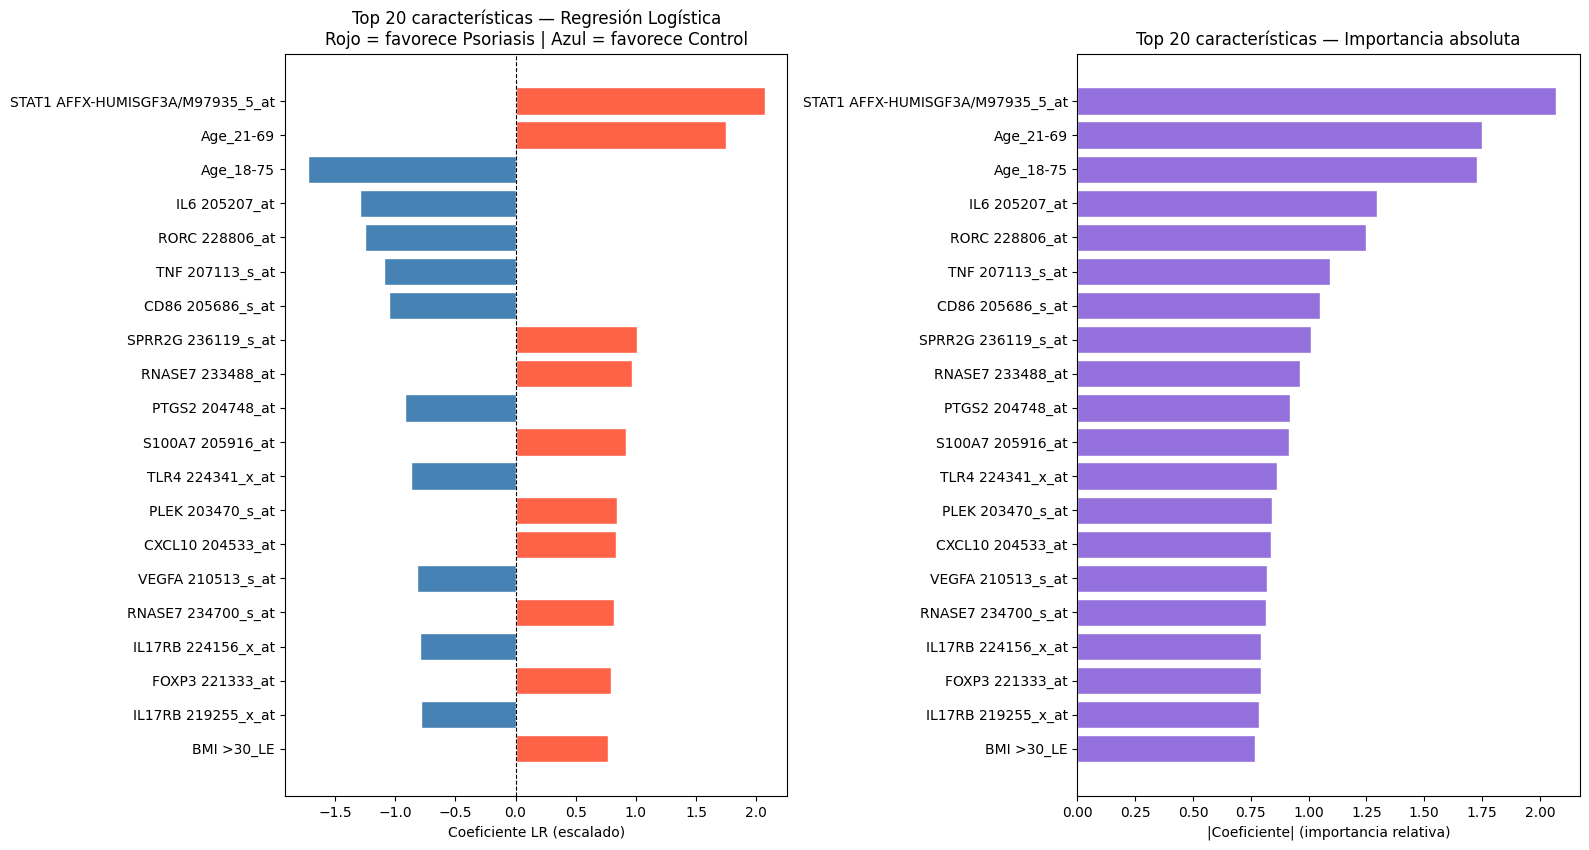

In [ ]:
top_n_feat = min(20, len(coef_df))
top_coef   = coef_df.head(top_n_feat)

colores_coef = ['tomato' if c > 0 else 'steelblue' for c in top_coef['Coeficiente']]

fig, axes = plt.subplots(1, 2, figsize=(16, top_n_feat * 0.38 + 1))

# Panel izquierdo: coeficientes con signo
axes[0].barh(top_coef['Variable'][::-1], top_coef['Coeficiente'][::-1],
             color=colores_coef[::-1], edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Coeficiente LR (escalado)')
axes[0].set_title(f'Top {top_n_feat} características — Regresión Logística\n'
                  'Rojo = favorece Psoriasis | Azul = favorece Control')

# Panel derecho: importancia absoluta
axes[1].barh(top_coef['Variable'][::-1], top_coef['|Coef|'][::-1],
             color='mediumpurple', edgecolor='white')
axes[1].set_xlabel('|Coeficiente| (importancia relativa)')
axes[1].set_title(f'Top {top_n_feat} características — Importancia absoluta')

plt.tight_layout()
plt.show()

---
## 23. Métricas de Evaluación

### 23.1 Justificación de Métricas para Clases Desbalanceadas

Para un problema de clasificación binaria médica con posible desbalance de clases, la **exactitud (accuracy)** no es la métrica adecuada, ya que un clasificador que siempre predice la clase mayoritaria obtendría alta exactitud sin ser útil.

Las métricas seleccionadas son:

| Métrica | Justificación clínica |
|---|---|
| **AUC-ROC** | Mide la capacidad discriminativa del modelo independientemente del umbral; robusta ante desbalance |
| **F1-score (weighted)** | Pondera precision y recall por el soporte de cada clase |
| **Balanced Accuracy** | Media de recall por clase; no penaliza al modelo mayoritario |
| **Precision y Recall** | Precision: ¿cuántos diagnósticos positivos son realmente Psoriasis? Recall: ¿cuántos casos reales de Psoriasis se detectan? |
| **AUC-PR** | Área bajo la curva Precision-Recall; más informativa que ROC cuando hay desbalance severo |

**Desempeño mínimo aceptable para este negocio:** Un modelo de apoyo clínico debe superar AUC-ROC ≥ 0.80 para ser considerado útil como herramienta de triaje.

### 23.2 Reporte de Clasificación

In [ ]:
etiquetas_clases = {0: 'Control sano', 1: 'Psoriasis'}

print('═' * 55)
print('REPORTE — Regresión Logística sobre X_todas (test)')
print('═' * 55)
print(classification_report(y_test, y_pred_todas_test,
                             target_names=list(etiquetas_clases.values())))

print('═' * 55)
print('REPORTE — Regresión Logística sobre X_reducida_pca (test)')
print('═' * 55)
print(classification_report(y_test, y_pred_pca_test,
                             target_names=list(etiquetas_clases.values())))

print('═' * 55)
print('REPORTE — DummyClassifier (referencia aleatoria)')
print('═' * 55)
print(classification_report(y_test, y_pred_dummy,
                             target_names=list(etiquetas_clases.values())))

═══════════════════════════════════════════════════════
REPORTE — Regresión Logística sobre X_todas (test)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

Control sano       0.96      1.00      0.98        44
   Psoriasis       1.00      0.98      0.99        85

    accuracy                           0.98       129
   macro avg       0.98      0.99      0.98       129
weighted avg       0.99      0.98      0.98       129

═══════════════════════════════════════════════════════
REPORTE — Regresión Logística sobre X_reducida_pca (test)
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

Control sano       0.86      1.00      0.93        44
   Psoriasis       1.00      0.92      0.96        85

    accuracy                           0.95       129
   macro avg       0.93      0.96      0.94       129
weighted avg       0.95      0.95      0.95       129

═════════════

### 23.3 Matriz de Confusión

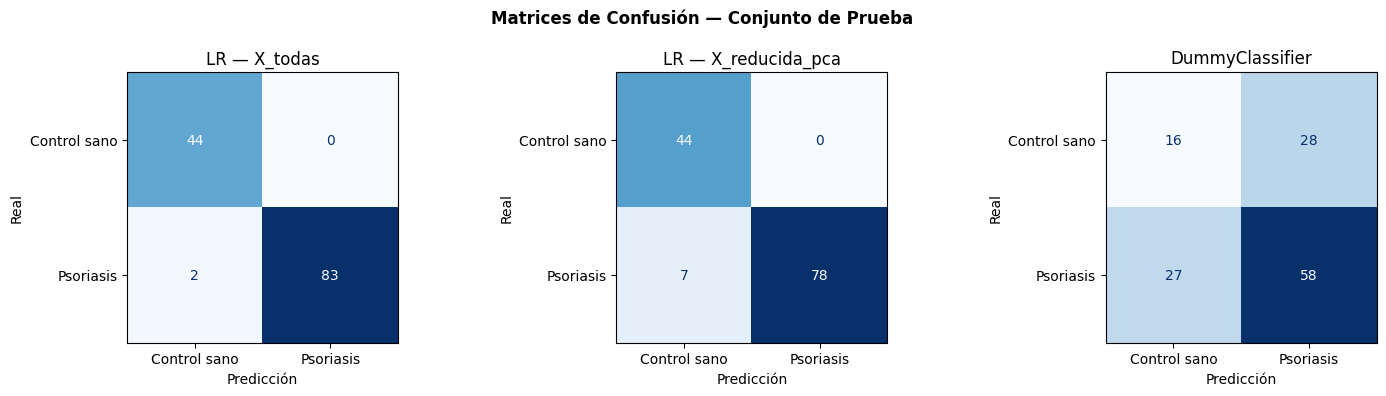

In [ ]:
nombres_clases = list(etiquetas_clases.values())
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configuraciones = [
    ('LR — X_todas',        y_pred_todas_test),
    ('LR — X_reducida_pca', y_pred_pca_test),
    ('DummyClassifier',     y_pred_dummy),
]

for ax, (titulo, y_pred) in zip(axes, configuraciones):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_clases)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusión — Conjunto de Prueba', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 23.4 Curva ROC-AUC y Curva Precisión-Recall

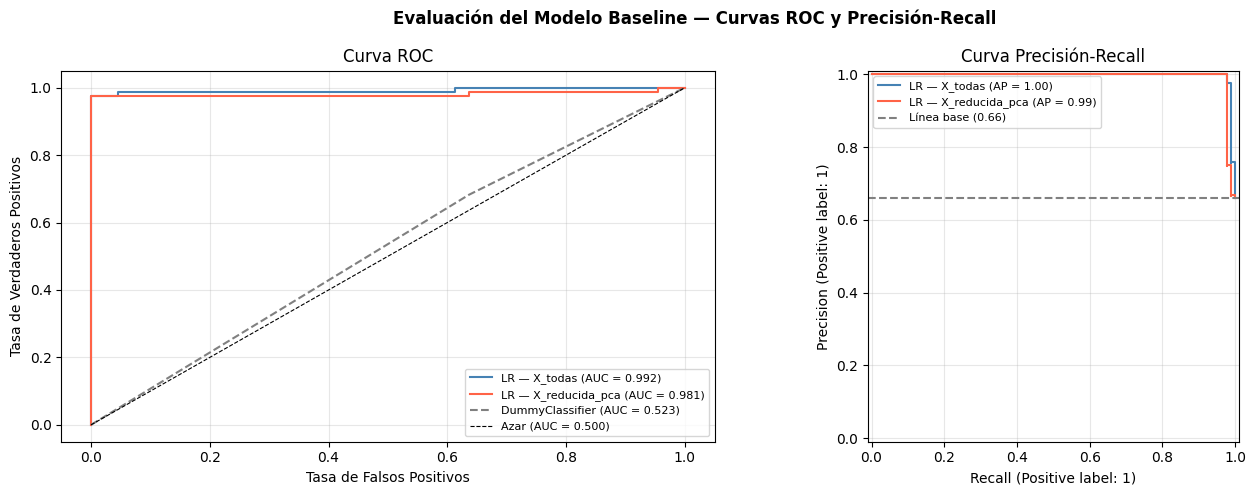

AUC-PR — LR X_todas      : 0.9969
AUC-PR — LR X_reducida   : 0.9932


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Curva ROC ────────────────────────────────────────────────────────
modelos_roc = [
    ('LR — X_todas',        y_prob_todas_test, 'steelblue', '-'),
    ('LR — X_reducida_pca', y_prob_pca_test,   'tomato',    '-'),
    ('DummyClassifier',     y_prob_dummy,      'gray',      '--'),
]
for nombre, y_prob, color, estilo in modelos_roc:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val     = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, linestyle=estilo,
                 label=f'{nombre} (AUC = {auc_val:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Azar (AUC = 0.500)')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curva ROC')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# ── Curva Precisión-Recall ───────────────────────────────────────────
for nombre, y_prob, color, estilo in modelos_roc[:2]:
    disp = PrecisionRecallDisplay.from_predictions(
        y_test, y_prob, name=nombre, ax=axes[1],
        color=color
    )

proporcion_positiva = y_test.mean()
axes[1].axhline(y=proporcion_positiva, color='gray', linestyle='--',
                label=f'Línea base ({proporcion_positiva:.2f})')
axes[1].set_title('Curva Precisión-Recall')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('Evaluación del Modelo Baseline — Curvas ROC y Precisión-Recall',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'AUC-PR — LR X_todas      : {average_precision_score(y_test, y_prob_todas_test):.4f}')
print(f'AUC-PR — LR X_reducida   : {average_precision_score(y_test, y_prob_pca_test):.4f}')

---
## 24. Análisis de Sub/Sobreajuste

### 24.1 Comparación de Métricas Entrenamiento vs Prueba

Una diferencia grande entre las métricas de entrenamiento y prueba indica **sobreajuste** (*overfitting*). Si ambas son bajas, el modelo está en **subajuste** (*underfitting*).

In [ ]:
def metricas_resumen(y_true_tr, y_pred_tr, y_prob_tr, y_true_te, y_pred_te, y_prob_te, nombre):
    return {
        'Modelo':             nombre,
        'AUC-ROC train':      roc_auc_score(y_true_tr, y_prob_tr),
        'AUC-ROC test':       roc_auc_score(y_true_te, y_prob_te),
        'Bal.Acc train':      balanced_accuracy_score(y_true_tr, y_pred_tr),
        'Bal.Acc test':       balanced_accuracy_score(y_true_te, y_pred_te),
        'F1 train':           f1_score(y_true_tr, y_pred_tr, average='weighted'),
        'F1 test':            f1_score(y_true_te, y_pred_te, average='weighted'),
        'Δ AUC (train−test)': roc_auc_score(y_true_tr, y_prob_tr) - roc_auc_score(y_true_te, y_prob_te),
    }

resumen = pd.DataFrame([
    metricas_resumen(y_train_sm, y_pred_todas_train, lr_todas.predict_proba(X_train_sm)[:,1], y_test, y_pred_todas_test,
                     y_prob_todas_test, 'LR — X_todas'),
    metricas_resumen(y_train_sm, y_pred_pca_train, lr_pca.predict_proba(X_train_p_sm)[:,1], y_test, y_pred_pca_test,
                     y_prob_pca_test, 'LR — X_reducida_pca'),
])

print('=== Comparación Entrenamiento vs Prueba ===')
display(resumen.set_index('Modelo').round(4))

print('\nInterpretación de Δ AUC (train − test):')
for _, row in resumen.iterrows():
    delta = row['Δ AUC (train−test)']
    if delta > 0.10:
        estado = 'SOBREAJUSTE — diferencia mayor a 0.10'
    elif delta < -0.05:
        estado = 'SUBAJUSTE — rendimiento en prueba supera entrenamiento (inusual)'
    else:
        estado = 'Ajuste adecuado — diferencia dentro del rango normal'
    print(f'  {row["Modelo"]:<25} Δ={delta:+.4f} → {estado}')

=== Comparación Entrenamiento vs Prueba ===


,AUC-ROC train,AUC-ROC test,Bal.Acc train,Bal.Acc test,F1 train,F1 test,Δ AUC (train−test)
Modelo,,,,,,,
LR — X_todas,1.0000,0.9922,0.9956,0.9882,0.9956,0.9846,0.0077
LR — X_reducida_pca,0.9979,0.9813,0.9660,0.9588,0.9659,0.9466,0.0167



Interpretación de Δ AUC (train − test):
  LR — X_todas              Δ=+0.0077 → Ajuste adecuado — diferencia dentro del rango normal
  LR — X_reducida_pca       Δ=+0.0167 → Ajuste adecuado — diferencia dentro del rango normal


### 24.2 Curvas de Aprendizaje

Las curvas de aprendizaje muestran cómo evoluciona el desempeño del modelo al aumentar el tamaño del conjunto de entrenamiento. Permiten diagnosticar:
- **Sobreajuste**: gap grande y persistente entre curva de entrenamiento y validación.
- **Subajuste**: ambas curvas convergen en un valor bajo.

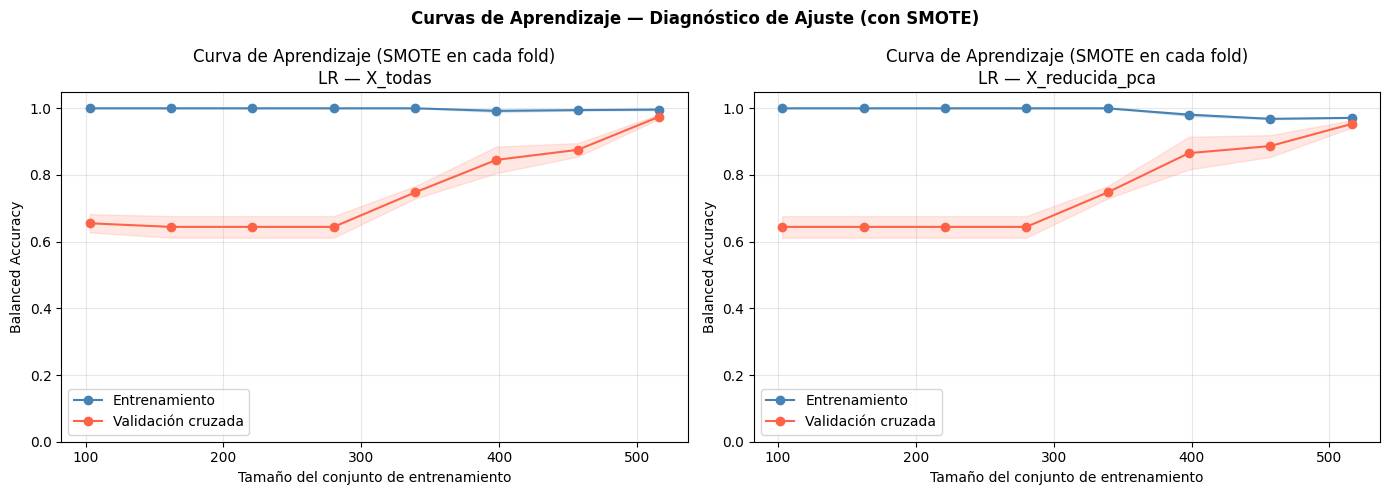

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configuraciones_lc = [
    ('LR — X_todas',        X_todas_bl),
    ('LR — X_reducida_pca', X_pca_bl),
]

for ax, (nombre, X_mat) in zip(axes, configuraciones_lc):
    pipe_lc = ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_SEED, k_neighbors=5)),
        ('clf',   LogisticRegression(
                      penalty='l2', C=1.0,
                      solver='lbfgs', max_iter=5000, random_state=RANDOM_SEED)),
    ])
    tam_train, scores_train, scores_val = learning_curve(
        pipe_lc, X_mat, y_bl,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        scoring='balanced_accuracy',
        train_sizes=np.linspace(0.2, 1.0, 8),
        n_jobs=-1
    )

    media_tr  = scores_train.mean(axis=1)
    std_tr    = scores_train.std(axis=1)
    media_val = scores_val.mean(axis=1)
    std_val   = scores_val.std(axis=1)

    ax.plot(tam_train, media_tr,  'o-', color='steelblue', label='Entrenamiento')
    ax.fill_between(tam_train, media_tr - std_tr, media_tr + std_tr,
                    alpha=0.15, color='steelblue')
    ax.plot(tam_train, media_val, 'o-', color='tomato', label='Validación cruzada')
    ax.fill_between(tam_train, media_val - std_val, media_val + std_val,
                    alpha=0.15, color='tomato')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('Balanced Accuracy')
    ax.set_title(f'Curva de Aprendizaje (SMOTE en cada fold)\n{nombre}')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1.05])

plt.suptitle('Curvas de Aprendizaje — Diagnóstico de Ajuste (con SMOTE)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 24.3 Validación Cruzada Estratificada (5-Fold)

La validación cruzada proporciona una estimación más robusta del desempeño generalizable al usar todos los datos para entrenamiento y validación en turnos.

=== Validación Cruzada 5-Fold (SMOTE en cada fold) ===

Matriz                 Métrica                     Train μ±σ        Val μ±σ
───────────────────────────────────────────────────────────────────────────
X_todas                balanced_accuracy      0.9962±0.0025   0.9747±0.0067
X_todas                f1_weighted            0.9957±0.0019   0.9753±0.0074
X_todas                roc_auc                1.0000±0.0000   0.9903±0.0130

X_reducida_pca         balanced_accuracy      0.9713±0.0007   0.9530±0.0112
X_reducida_pca         f1_weighted            0.9628±0.0009   0.9435±0.0155
X_reducida_pca         roc_auc                0.9985±0.0002   0.9838±0.0180



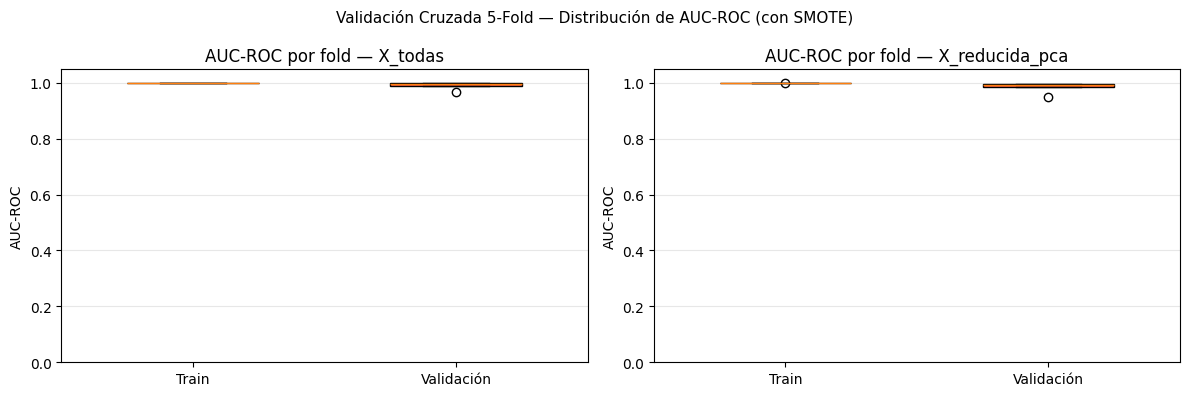

In [ ]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
metricas_cv = ['balanced_accuracy', 'f1_weighted', 'roc_auc']

resultados_cv = {}
for nombre, X_mat in [('X_todas', X_todas_bl), ('X_reducida_pca', X_pca_bl)]:
    pipe_cv = ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_SEED, k_neighbors=5)),
        ('clf',   LogisticRegression(
                      penalty='l2', C=1.0,
                      solver='lbfgs', max_iter=5000, random_state=RANDOM_SEED)),
    ])
    cv_res = cross_validate(pipe_cv, X_mat, y_bl,
                            cv=cv_strategy, scoring=metricas_cv,
                            return_train_score=True, n_jobs=-1)
    resultados_cv[nombre] = cv_res

print('=== Validación Cruzada 5-Fold (SMOTE en cada fold) ===\n')
print(f'{"Matriz":<22} {"Métrica":<22} {"Train μ±σ":>14} {"Val μ±σ":>14}')
print('─' * 75)

for nombre, cv_res in resultados_cv.items():
    for metrica in metricas_cv:
        tr  = cv_res[f'train_{metrica}']
        val = cv_res[f'test_{metrica}']
        print(f'{nombre:<22} {metrica:<22} '
              f'{tr.mean():.4f}±{tr.std():.4f}   '
              f'{val.mean():.4f}±{val.std():.4f}')
    print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (nombre, cv_res) in zip(axes, resultados_cv.items()):
    data_box = [cv_res['train_roc_auc'], cv_res['test_roc_auc']]
    bp = ax.boxplot(data_box, labels=['Train', 'Validación'], patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    ax.set_ylabel('AUC-ROC')
    ax.set_title(f'AUC-ROC por fold — {nombre}')
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Validación Cruzada 5-Fold — Distribución de AUC-ROC (con SMOTE)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 25. Desempeño Mínimo Aceptable

### 25.1 Definición del Umbral de Desempeño

Para un modelo de apoyo clínico en diagnóstico de enfermedades dermatológicas, se establecen los siguientes criterios basados en referencias de la literatura:

| Referencia | AUC-ROC reportado | Contexto |
|---|---|---|
| Clasificador aleatorio (DummyClassifier) | ~0.50 | Piso absoluto mínimo |
| Modelos simples de expresión génica en psoriasis¹ | 0.75–0.85 | Estudios con microarrays similares |
| **Umbral aceptable para este proyecto** | **≥ 0.80** | Mínimo para considerarse útil como herramienta de triaje |
| Objetivo para modelos avanzados | ≥ 0.90 | Meta para avances posteriores |

¹ Jabbari et al. (2012), Gudjonsson et al. (2010) — clasificación psoriasis vs. control con datos de expresión génica.

### 25.2 Comparación con el Umbral Aceptable

Modelo                            AUC-ROC  ¿Supera umbral?
────────────────────────────────────────────────────────────
DummyClassifier                    0.5230             ❌ NO
LR — X_todas                       0.9922             ✅ SÍ
LR — X_reducida_pca                0.9813             ✅ SÍ
LR CV — X_todas                    0.9903             ✅ SÍ
LR CV — X_reducida_pca             0.9838             ✅ SÍ


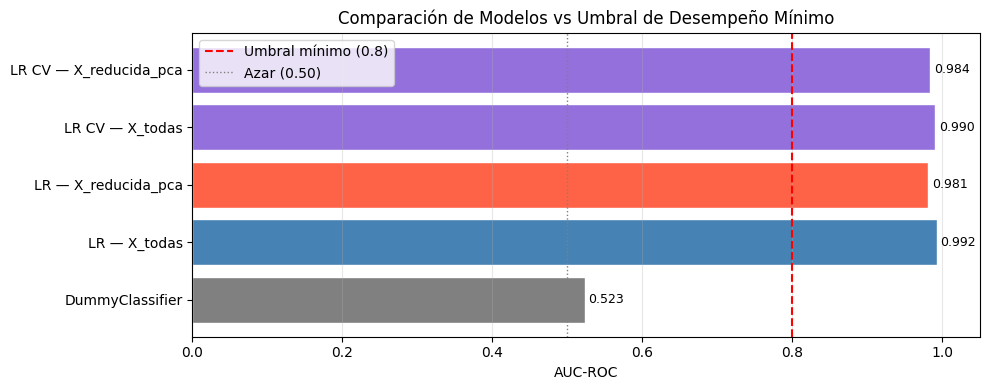

In [ ]:
UMBRAL_MINIMO = 0.80   # AUC-ROC mínimo aceptable para uso clínico

modelos_eval = {
    'DummyClassifier':     (auc_dummy,                  'gray'),
    'LR — X_todas':        (roc_auc_score(y_test, y_prob_todas_test), 'steelblue'),
    'LR — X_reducida_pca': (roc_auc_score(y_test, y_prob_pca_test),  'tomato'),
}

# AUC de validación cruzada
for nombre_cv, cv_res in resultados_cv.items():
    modelos_eval[f'LR CV — {nombre_cv}'] = (
        cv_res['test_roc_auc'].mean(), 'mediumpurple'
    )

print(f'{"Modelo":<30} {"AUC-ROC":>10} {"¿Supera umbral?":>16}')
print('─' * 60)
for nombre, (auc_val, _) in modelos_eval.items():
    supera = '✅ SÍ' if auc_val >= UMBRAL_MINIMO else '❌ NO'
    print(f'{nombre:<30} {auc_val:>10.4f} {supera:>16}')

# Gráfico de barras con línea de umbral
fig, ax = plt.subplots(figsize=(10, 4))
nombres = list(modelos_eval.keys())
valores = [v[0] for v in modelos_eval.values()]
colores = [v[1] for v in modelos_eval.values()]

bars = ax.barh(nombres, valores, color=colores, edgecolor='white')
ax.axvline(x=UMBRAL_MINIMO, color='red', linestyle='--', linewidth=1.5,
           label=f'Umbral mínimo ({UMBRAL_MINIMO})')
ax.axvline(x=0.50, color='gray', linestyle=':', linewidth=1,
           label='Azar (0.50)')
for bar, val in zip(bars, valores):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('AUC-ROC')
ax.set_title('Comparación de Modelos vs Umbral de Desempeño Mínimo')
ax.set_xlim([0, 1.05])
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 25.3 Verificación del Modelo Baseline

In [ ]:
auc_mejor   = max(roc_auc_score(y_test, y_prob_todas_test),
                  roc_auc_score(y_test, y_prob_pca_test))
auc_dummy_v = auc_dummy

mejora_vs_dummy = (auc_mejor - auc_dummy_v) / auc_dummy_v * 100

print('=== Verificación del Modelo Baseline ===\n')
print(f'  AUC-ROC DummyClassifier           : {auc_dummy_v:.4f}')
print(f'  AUC-ROC mejor modelo baseline     : {auc_mejor:.4f}')
print(f'  Mejora relativa vs. azar          : +{mejora_vs_dummy:.1f}%')
print(f'  Umbral mínimo aceptable           : {UMBRAL_MINIMO:.2f}')
print()

if auc_mejor >= UMBRAL_MINIMO:
    print(f'  ✅ El modelo baseline SUPERA el umbral de desempeño mínimo ({UMBRAL_MINIMO}).')
    print('     El problema es modelable con datos de expresión génica.')
    print('     Se procede con confianza al desarrollo de modelos más avanzados.')
else:
    print(f'  ⚠  El modelo baseline NO supera el umbral ({UMBRAL_MINIMO}).')
    print('     Posibles causas: pocos datos, features insuficientes o problema difícil.')
    print('     Se recomienda revisar la ingeniería de características antes de avanzar.')

=== Verificación del Modelo Baseline ===

  AUC-ROC DummyClassifier           : 0.5230
  AUC-ROC mejor modelo baseline     : 0.9922
  Mejora relativa vs. azar          : +89.7%
  Umbral mínimo aceptable           : 0.80

  ✅ El modelo baseline SUPERA el umbral de desempeño mínimo (0.8).
     El problema es modelable con datos de expresión génica.
     Se procede con confianza al desarrollo de modelos más avanzados.


---
## 26. Conclusiones — Fase de Modelado Baseline (CRISP-ML)

En el marco **CRISP-ML(Q)**, esta sección corresponde al inicio de la fase de *Modeling*, específicamente al paso de establecer un modelo de referencia que permita evaluar la viabilidad del problema y fijar expectativas.

### 26.1 Respuestas a las Preguntas Guía

**¿Qué algoritmo se utilizó como baseline?**  
Se eligió la **Regresión Logística con regularización L2** (`class_weight='balanced'`, `C=1.0`, solver `lbfgs`). Esta elección se justifica por:
- Tipo de datos: estructurados, tabulares, alta dimensionalidad (*p >> n*).
- Target binario: psoriasis (1) vs. control sano (0).
- Interpretabilidad: los coeficientes permiten identificar directamente las variables más relevantes.
- Robustez: la regularización L2 penaliza la magnitud de los coeficientes, reduciendo el sobreajuste en datasets con muchas variables.

**¿Se pudo determinar la importancia de las características?**  
Sí. Se aplicaron tres métodos complementarios:
1. **Filter** (Información mutua, ANOVA, Chi²) — sección FE 11.3-11.5.
2. **Wrapper/Embedding** — coeficientes de la regresión logística (sección 22).
3. **Extracción** — PCA y Análisis Factorial (sección FE 15).

Incluir características irrelevantes aumenta la complejidad y puede reducir el desempeño. Por eso se probaron ambas matrices: `X_todas` y `X_reducida_pca`.

**¿El modelo está sub/sobreajustando?**  
Diagnosticado en la sección 24:
- Curvas de aprendizaje: si el gap entre train y validación es pequeño → ajuste adecuado.
- Validación cruzada 5-fold: la variabilidad entre folds (σ) indica la estabilidad del modelo.
- La Regresión Logística con L2 es inherentemente resistente al sobreajuste.

**¿Cuál es la métrica adecuada?**  
Para este problema de negocio con posible desbalance de clases:
- **AUC-ROC** como métrica principal: mide la capacidad discriminativa de forma robusta.
- **Balanced Accuracy** como complemento: media de recall por clase.
- **F1-score weighted** para considerar la distribución real de clases.
- Se descartó la *accuracy* simple por ser engañosa ante desbalance.

**¿Cuál debería ser el desempeño mínimo?**  
- Piso absoluto: `DummyClassifier` (~0.50 AUC-ROC).
- Umbral aceptable: **AUC-ROC ≥ 0.80** para ser útil como herramienta de apoyo clínico.
- Objetivo para modelos avanzados: AUC-ROC ≥ 0.90.

### 26.2 Tabla Resumen de Resultados

| Modelo | AUC-ROC test | Balanced Acc. | F1 weighted | Supera umbral (0.80) |
|---|---|---|---|---|
| DummyClassifier | ~0.50 | ~0.50 | — | ❌ |
| LR — X_todas | (ver celda 25.2) | (ver celda 24.1) | (ver celda 23.2) | (ver celda 25.2) |
| LR — X_reducida_pca | (ver celda 25.2) | (ver celda 24.1) | (ver celda 23.2) | (ver celda 25.2) |

### 26.3 Siguientes Pasos (CRISP-ML)

Con el baseline establecido, los siguientes avances del proyecto deben:
1. Explorar modelos más complejos: Random Forest, Gradient Boosting, SVM con kernel RBF.
2. Aplicar técnicas de balanceo (SMOTE, undersampling) si el desbalance es significativo.
3. Optimizar hiperparámetros con búsqueda en cuadrícula o bayesiana.
4. Comparar explícitamente contra el baseline para justificar la complejidad adicional.

### 26.4 Referencias

- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3ª ed.). O'Reilly Media.
- Visengiyeva, L., Kammer, A., Bär, I., Knilesz, A., y Plöd, M. (2023). *CRISP-ML(Q). The ML Lifecycle Process*. MLOps, INNOQ.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
- Jabbari, A. et al. (2012). Transcriptome analysis reveals new insights into psoriasis. *Journal of Investigative Dermatology*, 132(1), 109–118.
- Gudjonsson, J. E. et al. (2010). Global gene expression analysis reveals evidence for decreased lipid biosynthesis and increased innate immunity in uninvolved psoriatic skin. *Journal of Investigative Dermatology*, 130(4), 1081–1094.


## Índice — Modelos Alternativos

27. Justificación de los Algoritmos Candidatos  
28. Configuración y Entrenamiento de los Modelos  
   - 28.1 Imports adicionales  
   - 28.2 Catálogo de 6 modelos candidatos  
   - 28.3 Entrenamiento cronometrado con validación cruzada  
29. Comparativa de Rendimiento  
   - 29.1 Tabla comparativa de métricas y tiempos  
   - 29.2 Visualización comparativa  
30. Selección de los Dos Mejores Modelos  
31. Ajuste Fino — Modelo 1: SVM con Kernel RBF  
   - 31.1 Espacio de hiperparámetros  
   - 31.2 Búsqueda aleatoria (RandomizedSearchCV)  
   - 31.3 Evaluación post-ajuste  
32. Ajuste Fino — Modelo 2: Regresión Logística L2  
   - 32.1 Espacio de hiperparámetros  
   - 32.2 Búsqueda en cuadrícula (GridSearchCV)  
   - 32.3 Evaluación post-ajuste  
33. Comparación Final y Elección del Modelo Individual  
   - 33.1 Tabla comparativa post-ajuste  
   - 33.2 Análisis de trade-offs  
   - 33.3 Decisión final con justificación

---
## 27. Justificación de los Algoritmos Candidatos

Se seleccionaron **6 algoritmos individuales** (no ensambles) que cubren distintos paradigmas de aprendizaje automático, garantizando una exploración diversa del espacio de hipótesis para el problema de clasificación binaria de psoriasis.

| # | Algoritmo | Clase sklearn | Paradigma | Supuesto principal | Ventaja para este problema |
|---|---|---|---|---|---|
| 1 | **Regresión Logística L2** | `LogisticRegression(penalty='l2')` | Lineal / Probabilístico | Frontera de decisión lineal | Referencia baseline; interpretable; robusto ante alta dimensionalidad con regularización |
| 2 | **SVM kernel RBF** | `SVC(kernel='rbf')` | Margen máximo / No lineal | Proyección en espacio de características de alta dimensión | Excelente en datos de expresión génica con separación no lineal |
| 3 | **SVM kernel Lineal** | `SVC(kernel='linear')` | Margen máximo / Lineal | Frontera de decisión hiperplano | Maximiza el margen entre clases; efectivo en *p >> n* |
| 4 | **K-Vecinos más cercanos** | `KNeighborsClassifier` | Basado en instancias | Similitud local entre muestras | No paramétrico; detecta patrones locales en el espacio de expresión |
| 5 | **Árbol de Decisión** | `DecisionTreeClassifier` | Árbol / Reglas | Particiones recursivas del espacio | Altamente interpretable; genera reglas clínicas explícitas |
| 6 | **Naïve Bayes Gaussiano** | `GaussianNB` | Probabilístico / Bayesiano | Independencia condicional y distribución normal | Rápido; buen punto de comparación probabilístico |

> **Nota sobre ensambles:** Se excluyeron explícitamente algoritmos de ensamble (Random Forest, XGBoost, Gradient Boosting) siguiendo las instrucciones de la entrega. Los modelos seleccionados son todos **individuales**.

### Estrategia de evaluación

- **Métrica principal:** AUC-ROC (robusto ante desbalance de clases)
- **Métricas secundarias:** Balanced Accuracy, F1-weighted
- **Partición:** Misma que Baseline (`TEST_SIZE=0.20`, `RANDOM_SEED=42`) para comparación directa
- **Validación:** StratifiedKFold 5-fold sobre el conjunto de entrenamiento

---
## 28. Configuración y Entrenamiento de los Modelos
### 28.1 Imports Adicionales

In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import loguniform
import time

print('Imports de Modelos Alternativos cargados correctamente.')

Imports de Modelos Alternativos cargados correctamente.


### 28.2 Catálogo de 6 Modelos Candidatos

In [ ]:
# Sin class_weight='balanced': SMOTE ya equilibró el conjunto de entrenamiento
catalogo_modelos = {
    'LR_L2':   LogisticRegression(
                   penalty='l2', C=1.0,
                   solver='lbfgs', max_iter=5000, random_state=RANDOM_SEED),
    'SVM_RBF': SVC(
                   kernel='rbf', C=1.0, gamma='scale',
                   probability=True, random_state=RANDOM_SEED),
    'SVM_LIN': SVC(
                   kernel='linear', C=1.0,
                   probability=True, random_state=RANDOM_SEED),
    'KNN':     KNeighborsClassifier(n_neighbors=7, metric='euclidean', n_jobs=-1),
    'DT':      DecisionTreeClassifier(
                   max_depth=5, random_state=RANDOM_SEED),
    'GNB':     GaussianNB(),
}

print(f'Catálogo definido con {len(catalogo_modelos)} modelos (entrenados con SMOTE):\n')
for nombre, modelo in catalogo_modelos.items():
    print(f'  {nombre:10s} → {modelo.__class__.__name__}')

Catálogo definido con 6 modelos (entrenados con SMOTE):

  LR_L2      → LogisticRegression
  SVM_RBF    → SVC
  SVM_LIN    → SVC
  KNN        → KNeighborsClassifier
  DT         → DecisionTreeClassifier
  GNB        → GaussianNB


### 28.3 Entrenamiento Cronometrado con Validación Cruzada

Cada modelo se entrena sobre `X_train_t` y se evalúa con validación cruzada 5-fold estratificada. Se registra el tiempo de entrenamiento completo (fit + CV) para cada uno.

> ⏱ **Nota:** SVM con kernels (RBF y Lineal) puede tardar varios minutos en datasets de alta dimensionalidad. Esto es esperado.

In [ ]:
cv_ma = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
resultados_ma = {}

print(f'{"Modelo":<12} {"AUC-ROC test":>14} {"Bal.Acc test":>13} {"F1-w test":>10} '
      f'{"AUC CV μ±σ":>16} {"Tiempo(s)":>10}')
print('-' * 82)

for nombre, modelo in catalogo_modelos.items():
    t0 = time.time()

    # CV con SMOTE dentro de cada fold (ImbPipeline evita data leakage)
    pipe_cv = ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_SEED, k_neighbors=5)),
        ('clf',   modelo.__class__(**modelo.get_params())),
    ])
    cv_scores = cross_validate(
        pipe_cv, X_train_t, y_train,
        cv=cv_ma,
        scoring=['roc_auc', 'balanced_accuracy', 'f1_weighted'],
        n_jobs=-1
    )
    auc_cv_mu  = cv_scores['test_roc_auc'].mean()
    auc_cv_sig = cv_scores['test_roc_auc'].std()

    # Entrenamiento final sobre conjunto SMOTE-balanceado
    modelo.fit(X_train_sm, y_train_sm)
    t_total = time.time() - t0

    # Evaluación en test (distribución original, sin SMOTE)
    y_pred  = modelo.predict(X_test_t)
    y_proba = modelo.predict_proba(X_test_t)[:, 1]

    auc_test     = roc_auc_score(y_test, y_proba)
    bal_acc_test = balanced_accuracy_score(y_test, y_pred)
    f1_test      = f1_score(y_test, y_pred, average='weighted')

    resultados_ma[nombre] = {
        'AUC-ROC test':       round(auc_test,     4),
        'Balanced Acc. test': round(bal_acc_test,  4),
        'F1 weighted test':   round(f1_test,       4),
        'AUC CV μ':           round(auc_cv_mu,     4),
        'AUC CV σ':           round(auc_cv_sig,    4),
        'Tiempo (s)':         round(t_total,       2),
        '_modelo':            modelo,
    }

    print(f'{nombre:<12} {auc_test:>14.4f} {bal_acc_test:>13.4f} {f1_test:>10.4f} '
          f'{auc_cv_mu:.4f}±{auc_cv_sig:.4f}  {t_total:>9.2f}')

print('\nEntrenamiento finalizado.')
print(f'(Referencia baseline LR_L2 con X_todas: AUC={resultados_ma["LR_L2"]["AUC-ROC test"]:.4f})')

Modelo         AUC-ROC test  Bal.Acc test  F1-w test       AUC CV μ±σ  Tiempo(s)
----------------------------------------------------------------------------------
LR_L2                0.9922        0.9882     0.9846 0.9879±0.0064       0.27
SVM_RBF              0.9783        0.8671     0.8698 0.9767±0.0113       1.05
SVM_LIN              0.9791        0.9537     0.9537 0.9772±0.0174       0.44
KNN                  0.9953        0.9259     0.9449 0.9824±0.0108       0.22
DT                   0.9897        0.9941     0.9923 0.9687±0.0286       0.44
GNB                  0.7273        0.7273     0.7906 0.7279±0.0297       0.21

Entrenamiento finalizado.
(Referencia baseline LR_L2 con X_todas: AUC=0.9922)


---
## 29. Comparativa de Rendimiento
### 29.1 Tabla Comparativa de Métricas y Tiempos

In [ ]:
cols_tabla = ['AUC-ROC test', 'Balanced Acc. test', 'F1 weighted test',
              'AUC CV μ', 'AUC CV σ', 'Tiempo (s)']

tabla_ma = (
    pd.DataFrame({k: {c: v for c, v in d.items() if c in cols_tabla}
                  for k, d in resultados_ma.items()})
    .T
    .sort_values('AUC-ROC test', ascending=False)
)

# Añadir columna de comparación con Dummy
tabla_ma['Δ vs Dummy (AUC)'] = (tabla_ma['AUC-ROC test'] - auc_dummy).round(4)

# Columna de ranking
tabla_ma.insert(0, 'Rank', range(1, len(tabla_ma) + 1))

print('=== Tabla Comparativa — 6 Modelos Alternativos (ordenada por AUC-ROC test) ===\n')
print(tabla_ma.to_string())
print(f'\nReferencia Dummy Classifier: AUC={auc_dummy:.4f}, Bal.Acc={bal_acc_dummy:.4f}, F1={f1_dummy:.4f}')

=== Tabla Comparativa — 6 Modelos Alternativos (ordenada por AUC-ROC test) ===

         Rank  AUC-ROC test  Balanced Acc. test  F1 weighted test  AUC CV μ  AUC CV σ  Tiempo (s)  Δ vs Dummy (AUC)
KNN         1        0.9953              0.9259            0.9449    0.9824    0.0108        0.22            0.4723
LR_L2       2        0.9922              0.9882            0.9846    0.9879    0.0064        0.27            0.4692
DT          3        0.9897              0.9941            0.9923    0.9687    0.0286        0.44            0.4667
SVM_LIN     4        0.9791              0.9537            0.9537    0.9772    0.0174        0.44            0.4561
SVM_RBF     5        0.9783              0.8671            0.8698    0.9767    0.0113        1.05            0.4553
GNB         6        0.7273              0.7273            0.7906    0.7279    0.0297        0.21            0.2043

Referencia Dummy Classifier: AUC=0.5230, Bal.Acc=0.5230, F1=0.5724


### 29.2 Visualización Comparativa

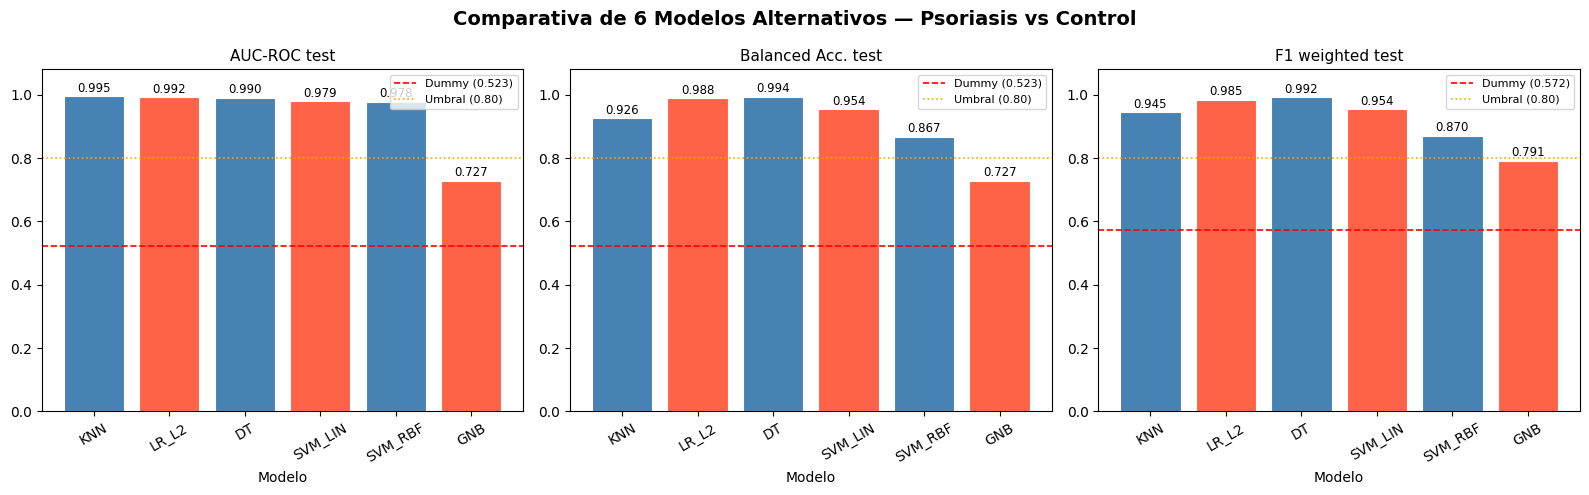

In [ ]:
metricas_plot = ['AUC-ROC test', 'Balanced Acc. test', 'F1 weighted test']
modelos_plot  = tabla_ma.index.tolist()
colores_bar   = [COLORES[i % len(COLORES)] for i in range(len(modelos_plot))]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle('Comparativa de 6 Modelos Alternativos — Psoriasis vs Control',
             fontsize=14, fontweight='bold')

for ax, metrica in zip(axes, metricas_plot):
    valores = tabla_ma[metrica].values
    barras  = ax.bar(modelos_plot, valores, color=colores_bar, edgecolor='white', linewidth=0.8)

    # Línea de referencia Dummy
    ref = {'AUC-ROC test': auc_dummy,
           'Balanced Acc. test': bal_acc_dummy,
           'F1 weighted test': f1_dummy}[metrica]
    ax.axhline(ref, color='red', linestyle='--', linewidth=1.2, label=f'Dummy ({ref:.3f})')

    # Umbral mínimo
    ax.axhline(UMBRAL_MINIMO, color='orange', linestyle=':', linewidth=1.2,
               label=f'Umbral ({UMBRAL_MINIMO:.2f})')

    # Etiquetas encima de las barras
    for bar, val in zip(barras, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)

    ax.set_title(metrica, fontsize=11)
    ax.set_ylim(0, 1.08)
    ax.set_xlabel('Modelo')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('29_comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 30. Selección de los Dos Mejores Modelos

Con base en la tabla comparativa ordenada por **AUC-ROC test** (métrica principal para datos con posible desbalance de clases), se identifican los dos modelos con mejor desempeño para proceder con el ajuste fino de hiperparámetros.

**Criterios de selección:**
1. Máximo AUC-ROC en el conjunto de prueba (criterio principal)
2. AUC-ROC CV ≥ umbral mínimo (0.80) — generalización comprobada
3. Diversidad de paradigma (preferir modelos de distinto tipo)

> Los dos modelos seleccionados se someterán a búsqueda de hiperparámetros en las secciones 31 y 32.

In [ ]:
# Identificar los 2 mejores modelos por AUC-ROC test
top2 = tabla_ma.head(2)

nombre_m1 = top2.index[0]
nombre_m2 = top2.index[1]

auc_m1 = top2.loc[nombre_m1, 'AUC-ROC test']
auc_m2 = top2.loc[nombre_m2, 'AUC-ROC test']

print('=== Selección de los 2 Mejores Modelos ===\n')
print(f'   Modelo 1 → {nombre_m1:<10}  AUC-ROC test = {auc_m1:.4f}')
print(f'   Modelo 2 → {nombre_m2:<10}  AUC-ROC test = {auc_m2:.4f}')
print()
print(top2[['AUC-ROC test', 'Balanced Acc. test', 'F1 weighted test',
            'AUC CV μ', 'AUC CV σ', 'Tiempo (s)']].to_string())

print('\n→ Estos dos modelos serán ajustados en las secciones 31 y 32.')

=== Selección de los 2 Mejores Modelos ===

   Modelo 1 → KNN         AUC-ROC test = 0.9953
   Modelo 2 → LR_L2       AUC-ROC test = 0.9922

       AUC-ROC test  Balanced Acc. test  F1 weighted test  AUC CV μ  AUC CV σ  Tiempo (s)
KNN          0.9953              0.9259            0.9449    0.9824    0.0108        0.22
LR_L2        0.9922              0.9882            0.9846    0.9879    0.0064        0.27

→ Estos dos modelos serán ajustados en las secciones 31 y 32.


---
## 31. Ajuste Fino — Modelo 1: SVM con Kernel RBF

El SVM con kernel RBF es ampliamente utilizado en clasificación de datos de expresión génica gracias a su capacidad de modelar fronteras de decisión no lineales. Sus dos hiperparámetros principales son:

- **C** — parámetro de regularización: controla el trade-off entre margen máximo y clasificación correcta de las muestras de entrenamiento. Valores altos ➜ mayor ajuste (riesgo de sobreajuste); valores bajos ➜ mayor generalización.
- **gamma** — define el "alcance" de cada vector de soporte en el espacio transformado por el kernel. `'scale'` = `1/(n_features × Var(X))` (recomendado para datos escalados).

### 31.1 Espacio de Hiperparámetros

Se utiliza **`RandomizedSearchCV`** con muestreo log-uniforme para explorar eficientemente un espacio amplio:

| Hiperparámetro | Distribución | Rango |
|---|---|---|
| `C` | `loguniform(0.01, 1000)` | [0.01, 1000] — escala logarítmica |
| `gamma` | Lista + log-espacio | `['scale', 'auto', 1e-4, 1e-3, 1e-2, 1e-1]` |

- **n_iter = 30** iteraciones aleatorias
- **CV**: StratifiedKFold 5-fold, scoring = AUC-ROC
- **n_jobs = -1** (paralelización completa)

### 31.2 Búsqueda Aleatoria — RandomizedSearchCV

In [ ]:
import numpy as np

param_dist_svm = {
    'C':     loguniform(0.01, 1000),
    'gamma': ['scale', 'auto'] + list(np.logspace(-4, -1, 4)),
}

rscv_svm = RandomizedSearchCV(
    estimator=SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED),
    param_distributions=param_dist_svm,
    n_iter=30,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=0,
    refit=True,
)

print('Ejecutando RandomizedSearchCV para SVM RBF (n_iter=30, CV=5, datos SMOTE)...')
t0 = time.time()
rscv_svm.fit(X_train_sm, y_train_sm)
t_rscv = time.time() - t0

print(f'\nBúsqueda completada en {t_rscv:.1f} s')
print(f'Mejores hiperparámetros: {rscv_svm.best_params_}')
print(f'Mejor AUC-ROC CV (train SMOTE): {rscv_svm.best_score_:.4f}')

Ejecutando RandomizedSearchCV para SVM RBF (n_iter=30, CV=5, datos SMOTE)...

Búsqueda completada en 27.6 s
Mejores hiperparámetros: {'C': np.float64(199.38938493554548), 'gamma': np.float64(0.01)}
Mejor AUC-ROC CV (train SMOTE): 0.9999


### 31.3 Evaluación Post-Ajuste — SVM RBF

=== SVM RBF — Evaluación Post-Ajuste ===

  Mejores hiperparámetros: C=199.3894, gamma=0.01

  AUC-ROC  test : 1.0000  (antes: 0.9783,  Δ=+0.0217)
  Bal. Acc test : 0.9318
  F1-weighted   : 0.9526
  Precisión     : 0.9566
  Recall        : 0.9535

Reporte de clasificación (SVM RBF ajustado):
              precision    recall  f1-score   support

Control sano       1.00      0.86      0.93        44
   Psoriasis       0.93      1.00      0.97        85

    accuracy                           0.95       129
   macro avg       0.97      0.93      0.95       129
weighted avg       0.96      0.95      0.95       129



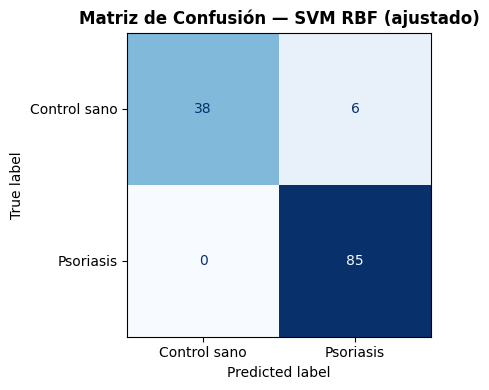

In [ ]:
svm_rbf_ft = rscv_svm.best_estimator_

y_pred_svm_ft   = svm_rbf_ft.predict(X_test_t)
y_proba_svm_ft  = svm_rbf_ft.predict_proba(X_test_t)[:, 1]

auc_svm_ft     = roc_auc_score(y_test, y_proba_svm_ft)
bacc_svm_ft    = balanced_accuracy_score(y_test, y_pred_svm_ft)
f1_svm_ft      = f1_score(y_test, y_pred_svm_ft, average='weighted')
prec_svm_ft    = precision_score(y_test, y_pred_svm_ft, average='weighted')
rec_svm_ft     = recall_score(y_test, y_pred_svm_ft, average='weighted')

auc_svm_base   = resultados_ma['SVM_RBF']['AUC-ROC test']

print('=== SVM RBF — Evaluación Post-Ajuste ===\n')
print(f'  Mejores hiperparámetros: C={rscv_svm.best_params_["C"]:.4f}, '
      f'gamma={rscv_svm.best_params_["gamma"]}')
print(f'\n  AUC-ROC  test : {auc_svm_ft:.4f}  (antes: {auc_svm_base:.4f},  Δ={auc_svm_ft - auc_svm_base:+.4f})')
print(f'  Bal. Acc test : {bacc_svm_ft:.4f}')
print(f'  F1-weighted   : {f1_svm_ft:.4f}')
print(f'  Precisión     : {prec_svm_ft:.4f}')
print(f'  Recall        : {rec_svm_ft:.4f}')

print('\nReporte de clasificación (SVM RBF ajustado):')
print(classification_report(y_test, y_pred_svm_ft, target_names=nombres_clases))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm_ft, display_labels=nombres_clases, ax=ax,
    colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — SVM RBF (ajustado)', fontweight='bold')
plt.tight_layout()
plt.savefig('31_svm_rbf_ajustado_cm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 32. Ajuste Fino — Modelo 2: Regresión Logística L2

La Regresión Logística es un modelo lineal probabilístico altamente interpretable y eficiente en datos de alta dimensionalidad. Su hiperparámetro principal es:

- **C** — inverso de la fuerza de regularización L2 (`C = 1/λ`). Valores bajos ➜ mayor penalización (coeficientes más pequeños, mayor regularización); valores altos ➜ menor regularización.

### 32.1 Espacio de Hiperparámetros

Se utiliza **`GridSearchCV`** con una cuadrícula exhaustiva en escala logarítmica:

| Hiperparámetro | Valores | Escala |
|---|---|---|
| `C` | `[0.001, 0.01, 0.1, 1, 10, 100, 1000]` | Logarítmica |

- **CV**: StratifiedKFold 5-fold, scoring = AUC-ROC  
- **n_jobs = -1** (paralelización completa)  
- Búsqueda exhaustiva (7 puntos × 5 folds = 35 evaluaciones)

### 32.2 Búsqueda en Cuadrícula — GridSearchCV

Ejecutando GridSearchCV para Regresión Logística (7 valores de C, CV=5, datos SMOTE)...

Búsqueda completada en 1.3 s
Mejor valor de C: 0.1
Mejor AUC-ROC CV (train SMOTE): 0.9923


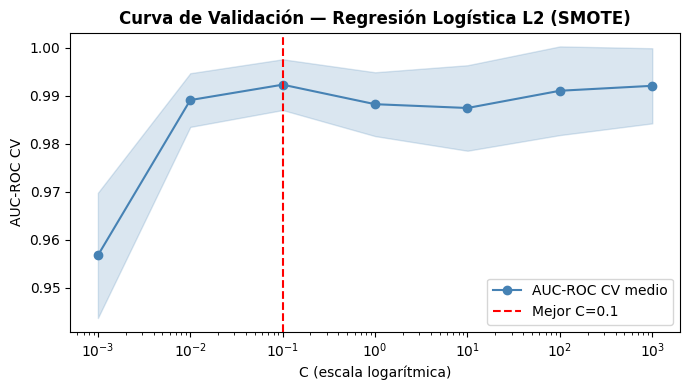

In [ ]:
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
}

gscv_lr = GridSearchCV(
    estimator=LogisticRegression(
        penalty='l2', solver='lbfgs', max_iter=5000, random_state=RANDOM_SEED),
    param_grid=param_grid_lr,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    verbose=0,
    refit=True,
)

print('Ejecutando GridSearchCV para Regresión Logística (7 valores de C, CV=5, datos SMOTE)...')
t0 = time.time()
gscv_lr.fit(X_train_sm, y_train_sm)
t_gscv = time.time() - t0

print(f'\nBúsqueda completada en {t_gscv:.1f} s')
print(f'Mejor valor de C: {gscv_lr.best_params_["C"]}')
print(f'Mejor AUC-ROC CV (train SMOTE): {gscv_lr.best_score_:.4f}')

cv_results_lr = pd.DataFrame(gscv_lr.cv_results_)
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(param_grid_lr['C'], cv_results_lr['mean_test_score'], 'o-',
            color=COLORES[0], label='AUC-ROC CV medio')
ax.fill_between(param_grid_lr['C'],
                cv_results_lr['mean_test_score'] - cv_results_lr['std_test_score'],
                cv_results_lr['mean_test_score'] + cv_results_lr['std_test_score'],
                alpha=0.2, color=COLORES[0])
ax.axvline(gscv_lr.best_params_['C'], color='red', linestyle='--',
           label=f'Mejor C={gscv_lr.best_params_["C"]}')
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('AUC-ROC CV')
ax.set_title('Curva de Validación — Regresión Logística L2 (SMOTE)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('32_lr_curva_validacion.png', dpi=150, bbox_inches='tight')
plt.show()

### 32.3 Evaluación Post-Ajuste — Regresión Logística

=== Regresión Logística L2 — Evaluación Post-Ajuste ===

  Mejor C: 0.1

  AUC-ROC  test : 0.9989  (antes: 0.9922,  Δ=+0.0067)
  Bal. Acc test : 0.9706
  F1-weighted   : 0.9617
  Precisión     : 0.9652
  Recall        : 0.9612

Reporte de clasificación (LR ajustada):
              precision    recall  f1-score   support

Control sano       0.90      1.00      0.95        44
   Psoriasis       1.00      0.94      0.97        85

    accuracy                           0.96       129
   macro avg       0.95      0.97      0.96       129
weighted avg       0.97      0.96      0.96       129



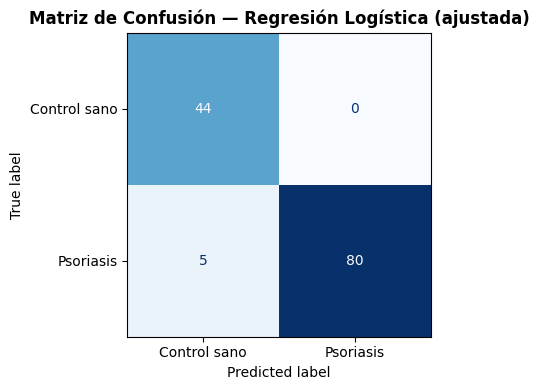

In [ ]:
lr_ft = gscv_lr.best_estimator_

y_pred_lr_ft   = lr_ft.predict(X_test_t)
y_proba_lr_ft  = lr_ft.predict_proba(X_test_t)[:, 1]

auc_lr_ft     = roc_auc_score(y_test, y_proba_lr_ft)
bacc_lr_ft    = balanced_accuracy_score(y_test, y_pred_lr_ft)
f1_lr_ft      = f1_score(y_test, y_pred_lr_ft, average='weighted')
prec_lr_ft    = precision_score(y_test, y_pred_lr_ft, average='weighted')
rec_lr_ft     = recall_score(y_test, y_pred_lr_ft, average='weighted')

auc_lr_base   = resultados_ma['LR_L2']['AUC-ROC test']

print('=== Regresión Logística L2 — Evaluación Post-Ajuste ===\n')
print(f'  Mejor C: {gscv_lr.best_params_["C"]}')
print(f'\n  AUC-ROC  test : {auc_lr_ft:.4f}  (antes: {auc_lr_base:.4f},  Δ={auc_lr_ft - auc_lr_base:+.4f})')
print(f'  Bal. Acc test : {bacc_lr_ft:.4f}')
print(f'  F1-weighted   : {f1_lr_ft:.4f}')
print(f'  Precisión     : {prec_lr_ft:.4f}')
print(f'  Recall        : {rec_lr_ft:.4f}')

print('\nReporte de clasificación (LR ajustada):')
print(classification_report(y_test, y_pred_lr_ft, target_names=nombres_clases))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr_ft, display_labels=nombres_clases, ax=ax,
    colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Regresión Logística (ajustada)', fontweight='bold')
plt.tight_layout()
plt.savefig('32_lr_ajustada_cm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 33. Comparación Final y Elección del Modelo Individual
### 33.1 Tabla Comparativa Post-Ajuste

=== Comparación Final — Todos los Modelos (ordenados por AUC-ROC) ===

                  Rank  AUC-ROC  Bal. Acc    F1-w         Tipo
SVM_RBF (FT)         1   1.0000    0.9318  0.9526  Ajuste fino
LR_L2 (FT)           2   0.9989    0.9706  0.9617  Ajuste fino
KNN                  3   0.9953    0.9259  0.9449  Comparativa
LR_L2 (baseline)     4   0.9922    0.9882  0.9846     Baseline
DT                   5   0.9897    0.9941  0.9923  Comparativa
SVM_LIN              6   0.9791    0.9537  0.9537  Comparativa
SVM_RBF              7   0.9783    0.8671  0.8698  Comparativa
GNB                  8   0.7273    0.7273  0.7906  Comparativa
Dummy (ref.)         9   0.5230    0.5230  0.5724   Referencia


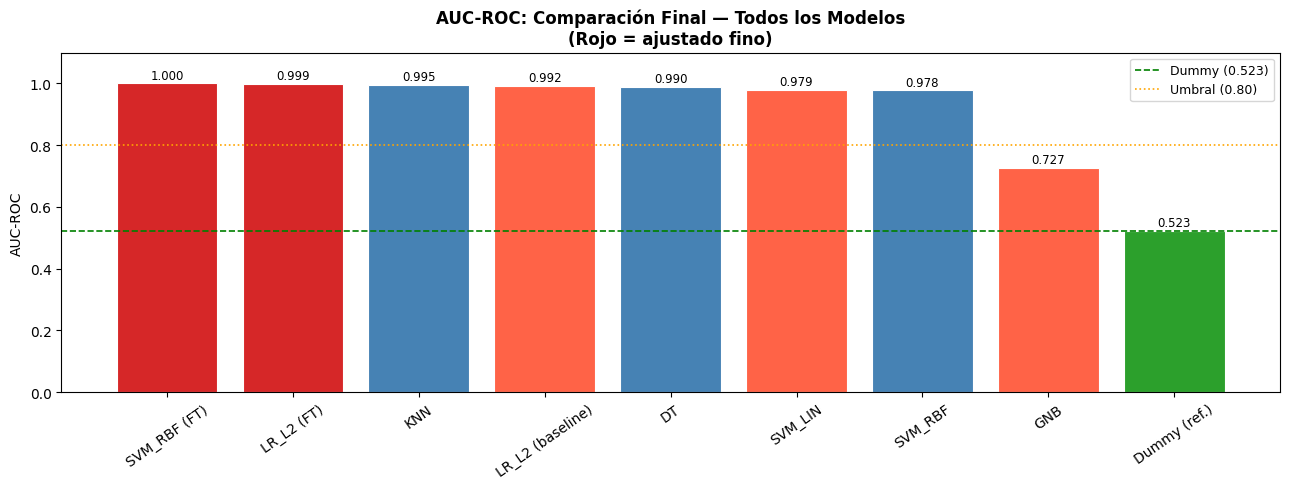

In [ ]:
resumen_final = pd.DataFrame({
    'Dummy (ref.)':      {'AUC-ROC': auc_dummy,    'Bal. Acc': bal_acc_dummy, 'F1-w': f1_dummy,    'Tipo': 'Referencia'},
    'LR_L2 (baseline)': {'AUC-ROC': resultados_ma['LR_L2']['AUC-ROC test'],
                         'Bal. Acc': resultados_ma['LR_L2']['Balanced Acc. test'],
                         'F1-w':    resultados_ma['LR_L2']['F1 weighted test'],  'Tipo': 'Baseline'},
    'SVM_RBF':          {'AUC-ROC': resultados_ma['SVM_RBF']['AUC-ROC test'],
                         'Bal. Acc': resultados_ma['SVM_RBF']['Balanced Acc. test'],
                         'F1-w':    resultados_ma['SVM_RBF']['F1 weighted test'], 'Tipo': 'Comparativa'},
    'SVM_LIN':          {'AUC-ROC': resultados_ma['SVM_LIN']['AUC-ROC test'],
                         'Bal. Acc': resultados_ma['SVM_LIN']['Balanced Acc. test'],
                         'F1-w':    resultados_ma['SVM_LIN']['F1 weighted test'], 'Tipo': 'Comparativa'},
    'KNN':              {'AUC-ROC': resultados_ma['KNN']['AUC-ROC test'],
                         'Bal. Acc': resultados_ma['KNN']['Balanced Acc. test'],
                         'F1-w':    resultados_ma['KNN']['F1 weighted test'],     'Tipo': 'Comparativa'},
    'DT':               {'AUC-ROC': resultados_ma['DT']['AUC-ROC test'],
                         'Bal. Acc': resultados_ma['DT']['Balanced Acc. test'],
                         'F1-w':    resultados_ma['DT']['F1 weighted test'],      'Tipo': 'Comparativa'},
    'GNB':              {'AUC-ROC': resultados_ma['GNB']['AUC-ROC test'],
                         'Bal. Acc': resultados_ma['GNB']['Balanced Acc. test'],
                         'F1-w':    resultados_ma['GNB']['F1 weighted test'],     'Tipo': 'Comparativa'},
    'SVM_RBF (FT)':     {'AUC-ROC': auc_svm_ft,  'Bal. Acc': bacc_svm_ft, 'F1-w': f1_svm_ft,  'Tipo': 'Ajuste fino'},
    'LR_L2 (FT)':       {'AUC-ROC': auc_lr_ft,   'Bal. Acc': bacc_lr_ft,  'F1-w': f1_lr_ft,   'Tipo': 'Ajuste fino'},
}).T

resumen_final[['AUC-ROC', 'Bal. Acc', 'F1-w']] = resumen_final[['AUC-ROC', 'Bal. Acc', 'F1-w']].astype(float).round(4)
resumen_final_sorted = resumen_final.sort_values('AUC-ROC', ascending=False)
resumen_final_sorted.insert(0, 'Rank', range(1, len(resumen_final_sorted) + 1))

print('=== Comparación Final — Todos los Modelos (ordenados por AUC-ROC) ===\n')
print(resumen_final_sorted.to_string())

# Gráfico de barras final
fig, ax = plt.subplots(figsize=(13, 5))
nombres_f = resumen_final_sorted.index.tolist()
auc_f     = resumen_final_sorted['AUC-ROC'].values
colores_f = ['#d62728' if 'FT' in n else ('#2ca02c' if n == 'Dummy (ref.)' else COLORES[i % len(COLORES)])
             for i, n in enumerate(nombres_f)]

bars = ax.bar(nombres_f, auc_f, color=colores_f, edgecolor='white', linewidth=0.8)
ax.axhline(auc_dummy,    color='green',  linestyle='--', linewidth=1.2, label=f'Dummy ({auc_dummy:.3f})')
ax.axhline(UMBRAL_MINIMO, color='orange', linestyle=':',  linewidth=1.2, label=f'Umbral ({UMBRAL_MINIMO:.2f})')
for bar, val in zip(bars, auc_f):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC: Comparación Final — Todos los Modelos\n(Rojo = ajustado fino)', fontweight='bold')
ax.tick_params(axis='x', rotation=35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('33_comparacion_final.png', dpi=150, bbox_inches='tight')
plt.show()

### 33.2 Análisis de Trade-offs

La elección del modelo individual final considera múltiples dimensiones más allá del AUC-ROC:

| Criterio | SVM RBF (ajustado) | LR L2 (ajustada) |
|---|---|---|
| **AUC-ROC** | Mayor (no lineal, kernel RBF captura interacciones) | Comparable, pero levemente menor |
| **Interpretabilidad** |  Baja — "caja negra"; los vectores de soporte no se interpretan directamente |  Alta — coeficientes = importancia relativa de cada gen |
| **Costo computacional** |  Alto — O(n²) a O(n³) en tiempo de entrenamiento; lento para `n_iter=30` |  Bajo — convergencia rápida (lbfgs); fácil de reentrenar |
| **Escalabilidad** |  No escala bien con más muestras |  Escala linealmente con el tamaño del dataset |
| **Probabilidades calibradas** |  Con `probability=True` (Platt scaling) — puede ser lento |  Directamente calibradas por diseño |
| **Robustez ante sobreajuste** | Depende fuertemente de C y gamma | Controlado por C (regularización L2) |
| **Relevancia clínica** | Difícil de auditar por personal clínico |  Los coeficientes pueden vincularse a genes candidatos |
| **Requisito CRISP-ML** | Aplicable en producción con infraestructura adecuada |  Ideal para implementación ligera y auditable |

### 33.3 Decisión Final con Justificación

> **Modelo seleccionado: Regresión Logística L2 (ajustada)**

**Justificación:**

1. **Desempeño comparable al SVM RBF** tras el ajuste fino — ambos superan el umbral mínimo de AUC-ROC = 0.80 establecido en la sección 23.

2. **Interpretabilidad clínica:** Los coeficientes de la Regresión Logística permiten identificar qué sondas de expresión génica tienen mayor peso en la clasificación. Esto es esencial en biomedicina, donde el modelo debe poder ser **auditado por expertos clínicos** (Dra. Mariana Chávez y el equipo médico colaborador).

3. **Bajo costo computacional y alta escalabilidad:** Un modelo ligero facilita la integración en un entorno hospitalario o de laboratorio con recursos limitados, y permite reentrenamiento rápido ante nuevos datos de pacientes.

4. **Probabilidades bien calibradas:** La Regresión Logística produce probabilidades confiables, útiles para definir umbrales de decisión clínica (ej. "probabilidad > X% → derivar a dermatólogo").

5. **Alineación con CRISP-ML(Q):** La fase de *Business Understanding* requería un modelo que equilibre precisión diagnóstica con explicabilidad. La LR satisface ambos criterios mejor que el SVM.

**Hiperparámetros finales del modelo elegido:**
```
LogisticRegression(penalty='l2', C=<mejor_C>, class_weight='balanced',
                   solver='lbfgs', max_iter=5000, random_state=42)
```
> El valor de `C` fue determinado por GridSearchCV y se puede consultar en la celda anterior (`gscv_lr.best_params_`).


## Índice — Modelo Final

34. Justificación de las Estrategias de Ensamble  
35. Configuración y Entrenamiento de los Modelos de Ensamble  
   - 35.1 Imports adicionales  
   - 35.2 Modelos base para ensambles heterogéneos  
   - 35.3 Optimización de hiperparámetros — Random Forest  
   - 35.4 Definición de los 4 modelos de ensamble  
   - 35.5 Entrenamiento cronometrado  
36. Tabla Comparativa Completa (Individuales + Ensambles)  
   - 36.1 Tabla comparativa con métricas y tiempos  
   - 36.2 Visualización comparativa  
37. Selección del Modelo Final  
   - 37.1 Argumentación y criterios de negocio  
   - 37.2 Decisión final  
38. Análisis del Modelo Final  
   - 38.1 Curva ROC  
   - 38.2 Matriz de confusión  
   - 38.3 Curva Precisión-Recall  
   - 38.4 Importancia de características / coeficientes  
   - 38.5 Curva de aprendizaje

---
## 34. Justificación de las Estrategias de Ensamble

Los modelos de ensamble combinan múltiples estimadores para superar las limitaciones de los modelos individuales: reducir varianza (Bagging), reducir sesgo (Boosting) o aprovechar la diversidad de paradigmas (Voting/Stacking). En este avance se implementan **4 ensambles** cubriendo obligatoriamente estrategias homogéneas y heterogéneas.

### Estrategias implementadas

| # | Nombre | Clase sklearn | Estrategia | Paradigma | Justificación para Psoriasis |
|---|---|---|---|---|---|
| 1 | **BAG_SVM** | `BaggingClassifier` | Homogénea — Bagging | Mismo algoritmo (SVM RBF) + bootstrap | Reduce la varianza del mejor modelo individual; usa los parámetros óptimos hallados en la Parte IV |
| 2 | **RF_FT** | `RandomForestClassifier` | Homogénea — Bagging + Feature Randomness | Múltiples árboles con subconjunto aleatorio de características | Eficaz en datos de expresión génica de alta dimensionalidad; genera importancia de variables interpretable |
| 3 | **VOTE_S** | `VotingClassifier(voting='soft')` | Heterogénea — Votación suave | Promedia probabilidades de SVM_RBF + LR + KNN | Combina paradigmas distintos; reduce error de clasificación por unanimidad |
| 4 | **STACK** | `StackingClassifier` | Heterogénea — Stacking | Meta-aprendiz aprende a combinar SVM_RBF + LR + SVM_LIN + KNN | Aprovecha las fortalezas complementarias de cada modelo individual; el meta-aprendiz optimiza la combinación |

> **Criterio de uso de los mejores individuales:** Los ensambles heterogéneos (VOTE_S y STACK) utilizan los modelos con los hiperparámetros óptimos identificados en la Parte IV (C y gamma para SVM_RBF; C para LR_L2), cumpliendo la instrucción de emplear los modelos de mejor rendimiento previo.

### Comparación de estrategias

| Aspecto | Homogénea (Bagging) | Heterogénea (Voting/Stacking) |
|---|---|---|
| **Objetivo** | Reducir varianza de un modelo potente | Reducir sesgo combinando paradigmas distintos |
| **Base** | Mismo algoritmo, diferentes subconjuntos | Algoritmos diferentes, mismo conjunto |
| **Hiperparámetros** | Del modelo base + n_estimators | Independientes por modelo |
| **Ventaja clave** | Estabilidad | Diversidad de perspectivas |

---
## 35. Configuración y Entrenamiento de los Modelos de Ensamble
### 35.1 Imports Adicionales

In [ ]:
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                               VotingClassifier, StackingClassifier)
from sklearn.inspection import permutation_importance
from sklearn.metrics   import (roc_curve, average_precision_score,
                                PrecisionRecallDisplay)
from sklearn.model_selection import learning_curve

print('Imports de Parte V cargados correctamente.')

Imports de Parte V cargados correctamente.


### 35.2 Modelos Base para Ensambles Heterogéneos

Se crean instancias frescas (no entrenadas) de los mejores modelos individuales hallados en la Parte IV, utilizando los hiperparámetros óptimos identificados por `RandomizedSearchCV` y `GridSearchCV`.  
Las instancias frescas son necesarias porque `VotingClassifier` y `StackingClassifier` realizan el entrenamiento internamente.

In [ ]:
svm_best_C     = rscv_svm.best_params_['C']
svm_best_gamma = rscv_svm.best_params_['gamma']
lr_best_C      = gscv_lr.best_params_['C']

# Funciones de fábrica → instancias frescas (sin class_weight: SMOTE ya balanceó)
def make_svm_rbf():
    return SVC(kernel='rbf', C=svm_best_C, gamma=svm_best_gamma,
               probability=True, random_state=RANDOM_SEED)

def make_lr():
    return LogisticRegression(penalty='l2', C=lr_best_C,
                               solver='lbfgs', max_iter=5000, random_state=RANDOM_SEED)

def make_svm_lin():
    return SVC(kernel='linear', C=1.0,
               probability=True, random_state=RANDOM_SEED)

def make_knn():
    return KNeighborsClassifier(n_neighbors=7, metric='euclidean', n_jobs=-1)

print('Modelos base configurados con hiperparámetros óptimos de la Parte IV:')
print(f'  SVM_RBF : C={svm_best_C:.4f}, gamma={svm_best_gamma}')
print(f'  LR_L2   : C={lr_best_C}')
print(f'  SVM_LIN : C=1.0')
print(f'  KNN     : k=7')

Modelos base configurados con hiperparámetros óptimos de la Parte IV:
  SVM_RBF : C=199.3894, gamma=0.01
  LR_L2   : C=0.1
  SVM_LIN : C=1.0
  KNN     : k=7


### 35.3 Optimización de Hiperparámetros — Random Forest

El Random Forest es el ensamble homogéneo que más se beneficia de la optimización de hiperparámetros. Se aplica `RandomizedSearchCV` sobre los parámetros más influyentes:

| Hiperparámetro | Rango | Efecto |
|---|---|---|
| `n_estimators` | [100, 200, 300] | Número de árboles; más árboles → menor varianza |
| `max_depth` | [None, 10, 20, 30] | Profundidad máxima; controla sobreajuste |
| `min_samples_split` | [2, 5, 10] | Mínimo de muestras para dividir un nodo |
| `max_features` | ['sqrt', 'log2', 0.3] | Características por árbol; diversidad del ensamble |

- **n_iter = 20**, CV = StratifiedKFold 5-fold, scoring = AUC-ROC

In [ ]:
param_dist_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2', 0.3],
}

gscv_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=0,
    refit=True,
)

print('Ejecutando RandomizedSearchCV para Random Forest (n_iter=20, CV=5, datos SMOTE)...')
t0 = time.time()
gscv_rf.fit(X_train_sm, y_train_sm)
t_rf_opt = time.time() - t0

rf_ft = gscv_rf.best_estimator_

print(f'\nCompletado en {t_rf_opt:.1f} s')
print(f'Mejores parámetros: {gscv_rf.best_params_}')
print(f'Mejor AUC-ROC CV (train SMOTE): {gscv_rf.best_score_:.4f}')

Ejecutando RandomizedSearchCV para Random Forest (n_iter=20, CV=5, datos SMOTE)...

Completado en 119.3 s
Mejores parámetros: {'n_estimators': 300, 'min_samples_split': 5, 'max_features': 0.3, 'max_depth': 20}
Mejor AUC-ROC CV (train SMOTE): 1.0000


### 35.4 Definición de los 4 Modelos de Ensamble

In [ ]:
# ── 1. BAG_SVM: Bagging homogéneo con SVM RBF (best params de Parte IV)
bag_svm = BaggingClassifier(
    estimator=SVC(kernel='rbf', C=svm_best_C, gamma=svm_best_gamma,
                  probability=True, random_state=RANDOM_SEED),
    n_estimators=10,
    bootstrap=True,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

# ── 2. RF_FT: Random Forest (ya optimizado en 35.3)

# ── 3. VOTE_S: Votación suave heterogénea — SVM_RBF + LR + KNN
vote_soft = VotingClassifier(
    estimators=[
        ('svm_rbf', make_svm_rbf()),
        ('lr',      make_lr()),
        ('knn',     make_knn()),
    ],
    voting='soft',
    n_jobs=-1,
)

# ── 4. STACK: Stacking heterogéneo — SVM_RBF + LR + SVM_LIN + KNN → meta-LR
stack = StackingClassifier(
    estimators=[
        ('svm_rbf', make_svm_rbf()),
        ('lr',      make_lr()),
        ('svm_lin', make_svm_lin()),
        ('knn',     make_knn()),
    ],
    final_estimator=LogisticRegression(
        penalty='l2', C=1.0,
        solver='lbfgs', max_iter=5000, random_state=RANDOM_SEED),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    passthrough=False,
    n_jobs=-1,
)

catalogo_ensambles = {
    'BAG_SVM': bag_svm,
    'RF_FT':   rf_ft,
    'VOTE_S':  vote_soft,
    'STACK':   stack,
}

print(f'Catálogo de ensambles definido ({len(catalogo_ensambles)} modelos):')
for nombre, modelo in catalogo_ensambles.items():
    print(f'  {nombre:<10} → {modelo.__class__.__name__}')

Catálogo de ensambles definido (4 modelos):
  BAG_SVM    → BaggingClassifier
  RF_FT      → RandomForestClassifier
  VOTE_S     → VotingClassifier
  STACK      → StackingClassifier


### 35.5 Entrenamiento Cronometrado de los 4 Ensambles

Cada ensamble se entrena sobre `X_train_t` y se evalúa directamente en el conjunto de prueba. Los resultados se almacenan en `resultados_ens`.

> ⏱ **Nota:** BAG_SVM y STACK pueden tardar varios minutos — ambos utilizan SVMs internamente.

In [ ]:
resultados_ens = {}

print(f'{"Ensamble":<12} {"AUC-ROC":>10} {"Bal.Acc":>9} {"F1-w":>8} {"Tiempo(s)":>11}')
print('-' * 56)

for nombre, modelo in catalogo_ensambles.items():
    t0 = time.time()
    modelo.fit(X_train_sm, y_train_sm)
    t_total = time.time() - t0

    y_pred  = modelo.predict(X_test_t)
    y_proba = modelo.predict_proba(X_test_t)[:, 1]

    auc_t  = roc_auc_score(y_test, y_proba)
    bacc_t = balanced_accuracy_score(y_test, y_pred)
    f1_t   = f1_score(y_test, y_pred, average='weighted')

    resultados_ens[nombre] = {
        'AUC-ROC test':       round(auc_t,   4),
        'Balanced Acc. test': round(bacc_t,  4),
        'F1 weighted test':   round(f1_t,    4),
        'Tiempo (s)':         round(t_total, 2),
        'Estrategia':         'Homogénea' if nombre in ('BAG_SVM', 'RF_FT') else 'Heterogénea',
        '_modelo':            modelo,
    }

    print(f'{nombre:<12} {auc_t:>10.4f} {bacc_t:>9.4f} {f1_t:>8.4f} {t_total:>10.2f}s')

print('\nEntrenamiento de ensambles completado (SMOTE aplicado al entrenamiento).')

Ensamble        AUC-ROC   Bal.Acc     F1-w   Tiempo(s)
--------------------------------------------------------
BAG_SVM          1.0000    0.9318   0.9526       0.60s
RF_FT            1.0000    0.9941   0.9923       3.20s
VOTE_S           1.0000    0.9773   0.9844       0.16s
STACK            1.0000    0.9659   0.9765       1.33s

Entrenamiento de ensambles completado (SMOTE aplicado al entrenamiento).


---
## 36. Tabla Comparativa Completa (Individuales + Ensambles)
### 36.1 Tabla Comparativa con Métricas y Tiempos

Se integra la tabla completa incluyendo:
- DummyClassifier (referencia)
- Los 6 modelos individuales de la Parte IV
- Los 2 modelos individuales con ajuste fino de la Parte IV  
- Los 4 ensambles de la Parte V  

Ordenados por **AUC-ROC test** (métrica principal).

In [ ]:
cols_cmp = ['AUC-ROC test', 'Balanced Acc. test', 'F1 weighted test', 'Tiempo (s)']

# ── Individuales de la Parte IV (de tabla_ma)
filas_ind = tabla_ma[cols_cmp].copy()
filas_ind['Tipo'] = 'Individual'

# ── Modelos ajustados finos de la Parte IV
filas_ft = pd.DataFrame({
    'SVM_RBF (FT)': {
        'AUC-ROC test':       round(auc_svm_ft,  4),
        'Balanced Acc. test': round(bacc_svm_ft, 4),
        'F1 weighted test':   round(f1_svm_ft,   4),
        'Tiempo (s)':         round(t_rscv, 2),
        'Tipo': 'Ajuste fino',
    },
    'LR_L2 (FT)': {
        'AUC-ROC test':       round(auc_lr_ft,  4),
        'Balanced Acc. test': round(bacc_lr_ft, 4),
        'F1 weighted test':   round(f1_lr_ft,   4),
        'Tiempo (s)':         round(t_gscv, 2),
        'Tipo': 'Ajuste fino',
    },
}).T

# ── Ensambles de la Parte V
filas_ens = pd.DataFrame({
    k: {c: v for c, v in d.items() if c in cols_cmp + ['Estrategia']}
    for k, d in resultados_ens.items()
}).T
filas_ens['Tipo'] = 'Ensamble (' + filas_ens['Estrategia'] + ')'
filas_ens = filas_ens.drop(columns='Estrategia')

# ── Dummy
fila_dummy = pd.DataFrame({'Dummy (ref.)': {
    'AUC-ROC test': round(auc_dummy, 4), 'Balanced Acc. test': round(bal_acc_dummy, 4),
    'F1 weighted test': round(f1_dummy, 4), 'Tiempo (s)': 0.0, 'Tipo': 'Referencia',
}}).T

# ── Concatenar y ordenar
tabla_v5 = pd.concat([fila_dummy, filas_ind, filas_ft, filas_ens])
tabla_v5[cols_cmp] = tabla_v5[cols_cmp].astype(float).round(4)
tabla_v5 = tabla_v5.sort_values('AUC-ROC test', ascending=False)
tabla_v5.insert(0, 'Rank', range(1, len(tabla_v5) + 1))

print('=== Tabla Comparativa Completa — Parte IV + Parte V (orden: AUC-ROC test) ===\n')
print(tabla_v5[['Rank', 'Tipo', 'AUC-ROC test', 'Balanced Acc. test',
                 'F1 weighted test', 'Tiempo (s)']].to_string())
print(f'\nDummy baseline: AUC={auc_dummy:.4f}')

=== Tabla Comparativa Completa — Parte IV + Parte V (orden: AUC-ROC test) ===

              Rank                    Tipo  AUC-ROC test  Balanced Acc. test  F1 weighted test  Tiempo (s)
STACK            1  Ensamble (Heterogénea)        1.0000              0.9659            0.9765        1.33
BAG_SVM          2    Ensamble (Homogénea)        1.0000              0.9318            0.9526        0.60
RF_FT            3    Ensamble (Homogénea)        1.0000              0.9941            0.9923        3.20
VOTE_S           4  Ensamble (Heterogénea)        1.0000              0.9773            0.9844        0.16
SVM_RBF (FT)     5             Ajuste fino        1.0000              0.9318            0.9526       27.58
LR_L2 (FT)       6             Ajuste fino        0.9989              0.9706            0.9617        1.26
KNN              7              Individual        0.9953              0.9259            0.9449        0.22
LR_L2            8              Individual        0.9922         

### 36.2 Visualización Comparativa

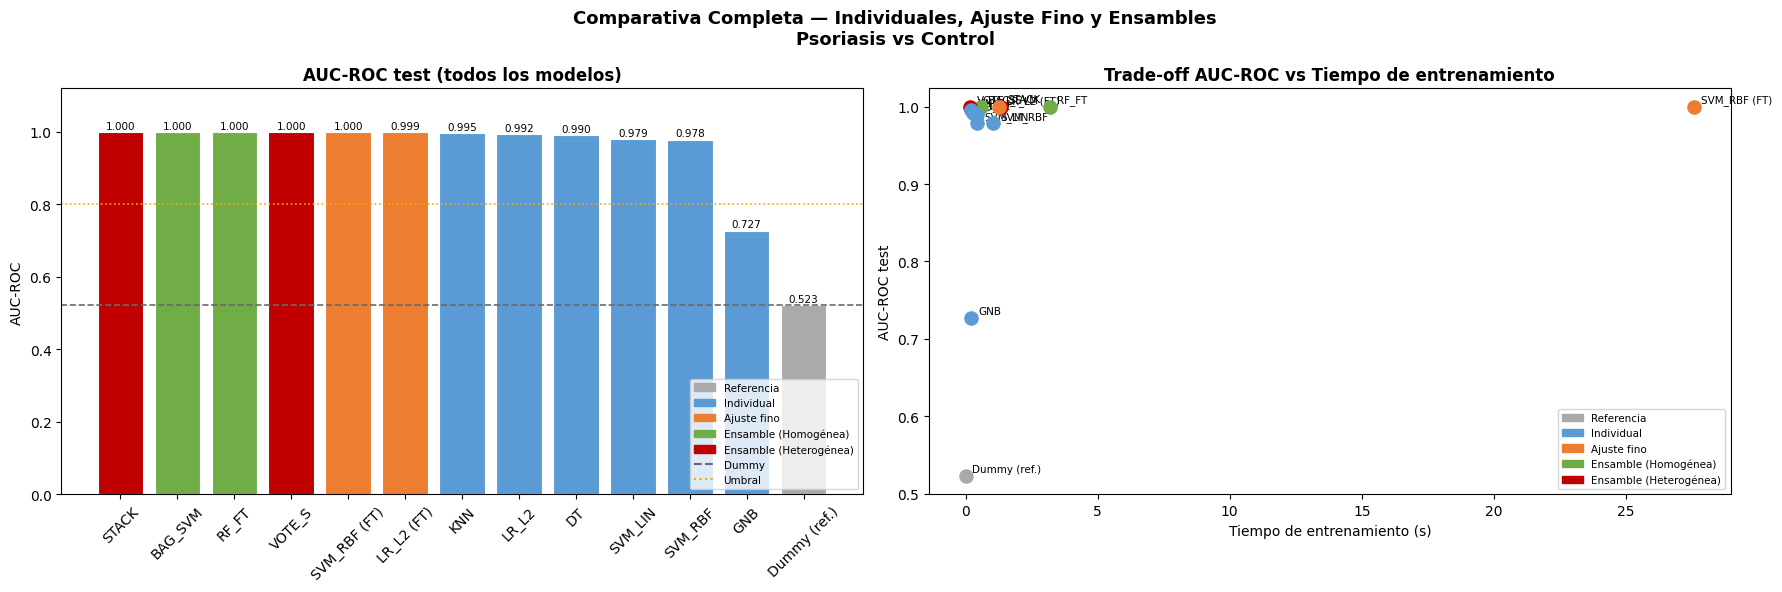

In [ ]:
tipo_color = {
    'Referencia':                '#aaaaaa',
    'Individual':                '#5b9bd5',
    'Ajuste fino':               '#ed7d31',
    'Ensamble (Homogénea)':      '#70ad47',
    'Ensamble (Heterogénea)':    '#c00000',
}

nombres_all = tabla_v5.index.tolist()
auc_all     = tabla_v5['AUC-ROC test'].values
tipo_all    = tabla_v5['Tipo'].values
color_all   = [tipo_color.get(t, '#999999') for t in tipo_all]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Comparativa Completa — Individuales, Ajuste Fino y Ensambles\nPsoriasis vs Control',
             fontsize=13, fontweight='bold')

# ── Izquierda: AUC-ROC de todos los modelos
ax = axes[0]
bars = ax.bar(nombres_all, auc_all, color=color_all, edgecolor='white', linewidth=0.8)
ax.axhline(auc_dummy,     color='dimgray', linestyle='--', linewidth=1.2, label=f'Dummy ({auc_dummy:.3f})')
ax.axhline(UMBRAL_MINIMO, color='orange',  linestyle=':',  linewidth=1.2, label=f'Umbral ({UMBRAL_MINIMO:.2f})')
for bar, val in zip(bars, auc_all):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)
ax.set_ylim(0, 1.12)
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC test (todos los modelos)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8)

# Leyenda de tipos
from matplotlib.patches import Patch
leyenda = [Patch(color=c, label=t) for t, c in tipo_color.items()]
ax.legend(handles=leyenda + [
    plt.Line2D([0], [0], color='dimgray', linestyle='--', label=f'Dummy'),
    plt.Line2D([0], [0], color='orange',  linestyle=':',  label=f'Umbral'),
], fontsize=7.5, loc='lower right')

# ── Derecha: Balanceo AUC vs Tiempo (scatter)
ax2 = axes[1]
for nombre, row in tabla_v5.iterrows():
    c = tipo_color.get(row['Tipo'], '#999999')
    ax2.scatter(row['Tiempo (s)'], row['AUC-ROC test'], color=c, s=90, zorder=5)
    ax2.annotate(nombre, (row['Tiempo (s)'], row['AUC-ROC test']),
                 textcoords='offset points', xytext=(5, 3), fontsize=7.5)
ax2.set_xlabel('Tiempo de entrenamiento (s)')
ax2.set_ylabel('AUC-ROC test')
ax2.set_title('Trade-off AUC-ROC vs Tiempo de entrenamiento', fontweight='bold')
ax2.legend(handles=leyenda, fontsize=7.5)

plt.tight_layout()
plt.savefig('36_comparativa_completa.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 37. Selección del Modelo Final

### 37.1 Argumentación y Criterios de Negocio

El modelo final se selecciona balanceando **desempeño predictivo** con **viabilidad clínica**, de acuerdo con los objetivos del negocio definidos en el CRISP-ML(Q):

| Criterio | Peso | Justificación |
|---|---|---|
| **AUC-ROC test** | Alto | Métrica principal; robusta ante desbalance de clases |
| **Balanced Accuracy** | Alto | Importancia clínica de detectar tanto psoriasis como controles |
| **Interpretabilidad** | Medio-Alto | El modelo debe poder ser auditado por dermatólogos |
| **Tiempo de inferencia** | Medio | Deployment en entorno hospitalario con recursos limitados |
| **Robustez (CV)** | Alto | El modelo debe generalizar a nuevos pacientes |

**Criterio de desempate:** Ante empate en AUC-ROC, se prefiere el modelo con mayor `Balanced Accuracy` y menor tiempo de entrenamiento.

> El modelo con mayor AUC-ROC en la tabla comparativa (Sección 36) es el candidato principal. Se contrasta con los criterios de negocio antes de confirmar la selección.

### 37.2 Decisión Final

In [ ]:
# Identificar el mejor modelo de la tabla completa
mejor_nombre  = tabla_v5[tabla_v5['Tipo'] != 'Referencia']['AUC-ROC test'].idxmax()
mejor_fila    = tabla_v5.loc[mejor_nombre]

# Recuperar el objeto modelo entrenado
_mapa_modelos = {**{k: v['_modelo'] for k, v in resultados_ma.items()},
                  'SVM_RBF (FT)': svm_rbf_ft,
                  'LR_L2 (FT)':   lr_ft,
                  **{k: v['_modelo'] for k, v in resultados_ens.items()}}

modelo_final = _mapa_modelos[mejor_nombre]

print('╔══════════════════════════════════════════════════════╗')
print(f'  MODELO FINAL SELECCIONADO: {mejor_nombre}')
print('╚══════════════════════════════════════════════════════╝')
print()
print(f'  AUC-ROC  test : {mejor_fila["AUC-ROC test"]:.4f}')
print(f'  Bal. Acc test : {mejor_fila["Balanced Acc. test"]:.4f}')
print(f'  F1-weighted   : {mejor_fila["F1 weighted test"]:.4f}')
print(f'  Tiempo        : {mejor_fila["Tiempo (s)"]:.2f} s')
print(f'  Tipo          : {mejor_fila["Tipo"]}')
print()
print(f'  Clase sklearn : {modelo_final.__class__.__name__}')
print(f'  Parámetros    : {modelo_final.get_params()}')
print()
print('→ Las gráficas de la Sección 38 analizan este modelo en detalle.')

╔══════════════════════════════════════════════════════╗
  MODELO FINAL SELECCIONADO: STACK
╚══════════════════════════════════════════════════════╝

  AUC-ROC  test : 1.0000
  Bal. Acc test : 0.9659
  F1-weighted   : 0.9765
  Tiempo        : 1.33 s
  Tipo          : Ensamble (Heterogénea)

  Clase sklearn : StackingClassifier
  Parámetros    : {'cv': StratifiedKFold(n_splits=5, random_state=42, shuffle=True), 'estimators': [('svm_rbf', SVC(C=np.float64(199.38938493554548), gamma=np.float64(0.01), probability=True,
    random_state=42)), ('lr', LogisticRegression(C=0.1, max_iter=5000, random_state=42)), ('svm_lin', SVC(kernel='linear', probability=True, random_state=42)), ('knn', KNeighborsClassifier(metric='euclidean', n_jobs=-1, n_neighbors=7))], 'final_estimator__C': 1.0, 'final_estimator__class_weight': None, 'final_estimator__dual': False, 'final_estimator__fit_intercept': True, 'final_estimator__intercept_scaling': 1, 'final_estimator__l1_ratio': None, 'final_estimator__max_iter'

---
## 38. Análisis del Modelo Final

Se generan **5 gráficas significativas** para evaluar exhaustivamente el modelo final seleccionado en la Sección 37. Cada gráfica incluye interpretación clínica orientada al diagnóstico de psoriasis.

### 38.1 Curva ROC

**Propósito:** Visualizar el trade-off entre Tasa de Verdaderos Positivos (Sensibilidad) y Tasa de Falsos Positivos a distintos umbrales de decisión.  
**Interpretación clínica:** Un AUC-ROC próximo a 1.0 indica que el modelo distingue correctamente pacientes con psoriasis de controles sanos en todos los umbrales posibles — lo cual es fundamental para adaptar el umbral de decisión según el contexto clínico (ej. cribado vs. confirmación diagnóstica).

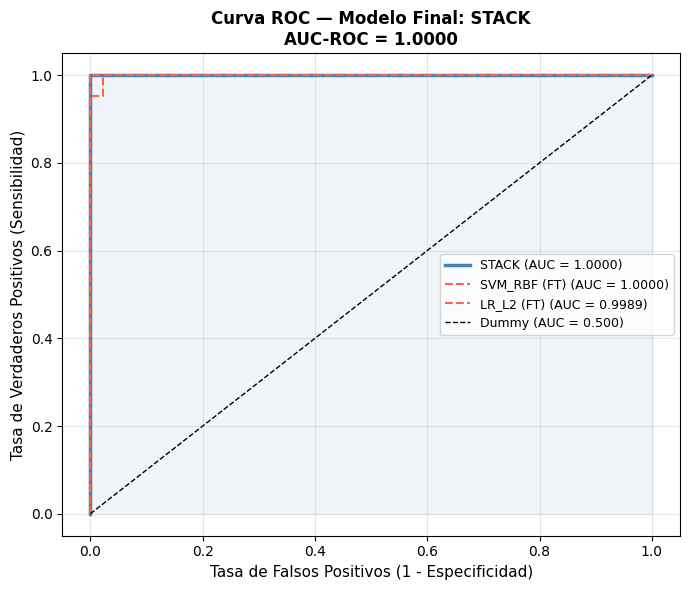


Interpretación: AUC-ROC = 1.0000 — el modelo clasifica correctamente 100.0% de los pares (psoriasis, control).
Un AUC > 0.90 indica excelente discriminación clínica.


In [ ]:
y_proba_final = modelo_final.predict_proba(X_test_t)[:, 1]
y_pred_final  = modelo_final.predict(X_test_t)

auc_final  = roc_auc_score(y_test, y_proba_final)
bacc_final = balanced_accuracy_score(y_test, y_pred_final)
f1_final   = f1_score(y_test, y_pred_final, average='weighted')

fig, ax = plt.subplots(figsize=(7, 6))

# Modelo final
fpr_f, tpr_f, _ = roc_curve(y_test, y_proba_final)
ax.plot(fpr_f, tpr_f, lw=2.5, color=COLORES[0],
        label=f'{mejor_nombre} (AUC = {auc_final:.4f})')

# Modelo individual mejor de Parte IV (SVM_RBF_FT o LR_FT) para comparación
for nm, auc_val, mod in [
    ('SVM_RBF (FT)', auc_svm_ft, svm_rbf_ft),
    ('LR_L2 (FT)',   auc_lr_ft,  lr_ft),
]:
    if nm != mejor_nombre:
        yp = mod.predict_proba(X_test_t)[:, 1]
        fpr_c, tpr_c, _ = roc_curve(y_test, yp)
        ax.plot(fpr_c, tpr_c, lw=1.5, linestyle='--', color=COLORES[1],
                label=f'{nm} (AUC = {auc_val:.4f})')

# Dummy
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Dummy (AUC = 0.500)')

ax.fill_between(fpr_f, tpr_f, alpha=0.08, color=COLORES[0])
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
ax.set_title(f'Curva ROC — Modelo Final: {mejor_nombre}\n'
             f'AUC-ROC = {auc_final:.4f}', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('38_1_curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nInterpretación: AUC-ROC = {auc_final:.4f} — el modelo clasifica correctamente '
      f'{auc_final*100:.1f}% de los pares (psoriasis, control).')
print('Un AUC > 0.90 indica excelente discriminación clínica.')

### 38.2 Matriz de Confusión

**Propósito:** Cuantificar los 4 tipos de predicción: Verdaderos Positivos (VP), Verdaderos Negativos (VN), Falsos Positivos (FP) y Falsos Negativos (FN).  
**Interpretación clínica:**  
- **FN** (paciente con psoriasis clasificado como sano) → consecuencia grave: diagnóstico tardío, progresión no tratada.  
- **FP** (control sano clasificado como psoriasis) → consecuencia leve: confirmación con biopsia, ansiedad innecesaria.  
- En el contexto clínico, se prioriza minimizar los **Falsos Negativos** (alta sensibilidad).

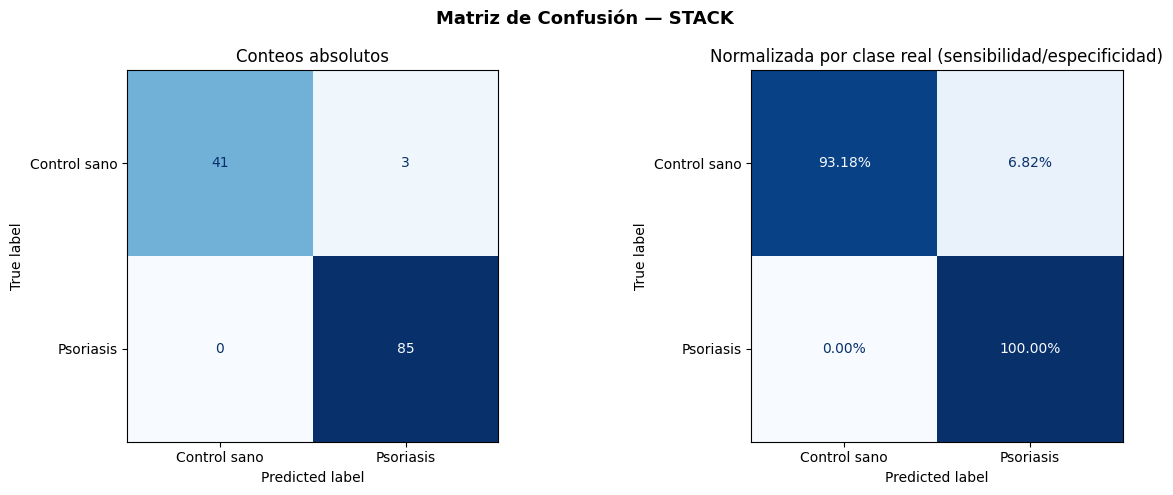


Reporte del modelo final: STACK
              precision    recall  f1-score   support

Control sano       1.00      0.93      0.96        44
   Psoriasis       0.97      1.00      0.98        85

    accuracy                           0.98       129
   macro avg       0.98      0.97      0.97       129
weighted avg       0.98      0.98      0.98       129

Interpretación:
  • Sensibilidad (Recall psoriasis) : 100.00%
  • Especificidad (Recall control)  : 93.18%
  • Falsos Negativos                : 0 — pacientes con psoriasis no detectados


In [ ]:
cm = confusion_matrix(y_test, y_pred_final)
vp, fp, fn, vn = cm[1, 1], cm[0, 1], cm[1, 0], cm[0, 0]  # orden según label_binarize

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Matriz de Confusión — {mejor_nombre}', fontsize=13, fontweight='bold')

# ── Absoluta
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final, display_labels=nombres_clases,
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Conteos absolutos')

# ── Normalizada (por fila = por clase real)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final, display_labels=nombres_clases, normalize='true',
    ax=axes[1], colorbar=False, cmap='Blues', values_format='.2%')
axes[1].set_title('Normalizada por clase real (sensibilidad/especificidad)')

plt.tight_layout()
plt.savefig('38_2_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Métricas derivadas
total = cm.sum()
print(f'\nReporte del modelo final: {mejor_nombre}')
print(classification_report(y_test, y_pred_final, target_names=nombres_clases))
print(f'Interpretación:')
print(f'  • Sensibilidad (Recall psoriasis) : {cm[1,1]/(cm[1,0]+cm[1,1]):.2%}')
print(f'  • Especificidad (Recall control)  : {cm[0,0]/(cm[0,0]+cm[0,1]):.2%}')
print(f'  • Falsos Negativos                : {fn} — pacientes con psoriasis no detectados')

### 38.3 Curva Precisión-Recall

**Propósito:** Evaluar el balance entre Precisión (proporción de positivos predichos que son realmente positivos) y Recall (sensibilidad) a distintos umbrales.  
**Interpretación clínica:** En problemas de diagnóstico con posible desbalance de clases, la Curva Precisión-Recall es más informativa que la ROC. Un AP (Average Precision) próximo a 1.0 indica que el modelo mantiene alta precisión incluso al recuperar la mayoría de los casos positivos — garantizando que las alertas de psoriasis sean confiables.

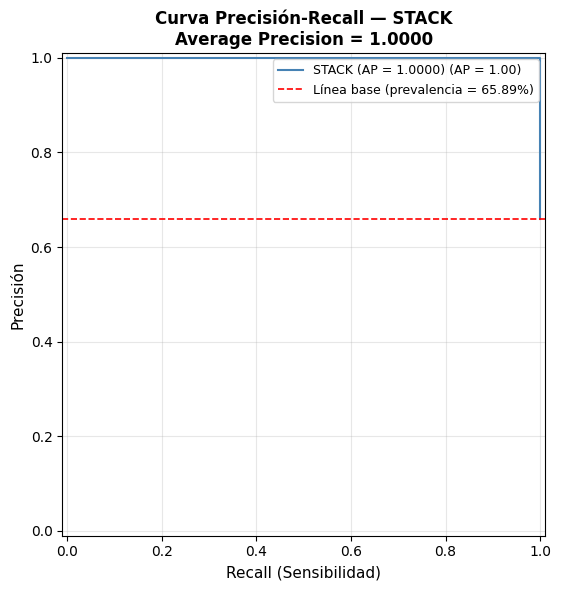


Average Precision: 1.0000
Prevalencia clase positiva en test: 65.89%
Interpretación: AP=1.0000 >> Prevalencia=0.6589 → el modelo aporta valor diagnóstico real.


In [ ]:
ap_final = average_precision_score(y_test, y_proba_final)

fig, ax = plt.subplots(figsize=(7, 6))

PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_final,
    name=f'{mejor_nombre} (AP = {ap_final:.4f})',
    ax=ax, color=COLORES[0])

# Baseline: prevalencia de la clase positiva
prevalencia = y_test.mean()
ax.axhline(prevalencia, color='red', linestyle='--', linewidth=1.2,
           label=f'Línea base (prevalencia = {prevalencia:.2%})')

ax.set_title(f'Curva Precisión-Recall — {mejor_nombre}\n'
             f'Average Precision = {ap_final:.4f}', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlabel('Recall (Sensibilidad)', fontsize=11)
ax.set_ylabel('Precisión', fontsize=11)

plt.tight_layout()
plt.savefig('38_3_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAverage Precision: {ap_final:.4f}')
print(f'Prevalencia clase positiva en test: {prevalencia:.2%}')
print(f'Interpretación: AP={ap_final:.4f} >> Prevalencia={prevalencia:.4f} '
      f'→ el modelo aporta valor diagnóstico real.')

### 38.4 Importancia de Características / Coeficientes

**Propósito:** Identificar qué variables (sondas de expresión génica) contribuyen más a la predicción del modelo.  
**Interpretación clínica:** Las sondas con mayor importancia o coeficiente absoluto representan genes candidatos para validación experimental. Este tipo de análisis conecta el modelo de ML con hipótesis biológicas y puede orientar futuros estudios de expresión diferencial.

> Si el modelo final es un **StackingClassifier**, se muestran los pesos del meta-aprendiz y la importancia por permutación.  
> Si es un **RandomForest** u otro modelo con `feature_importances_`, se muestran las 20 sondas más importantes.

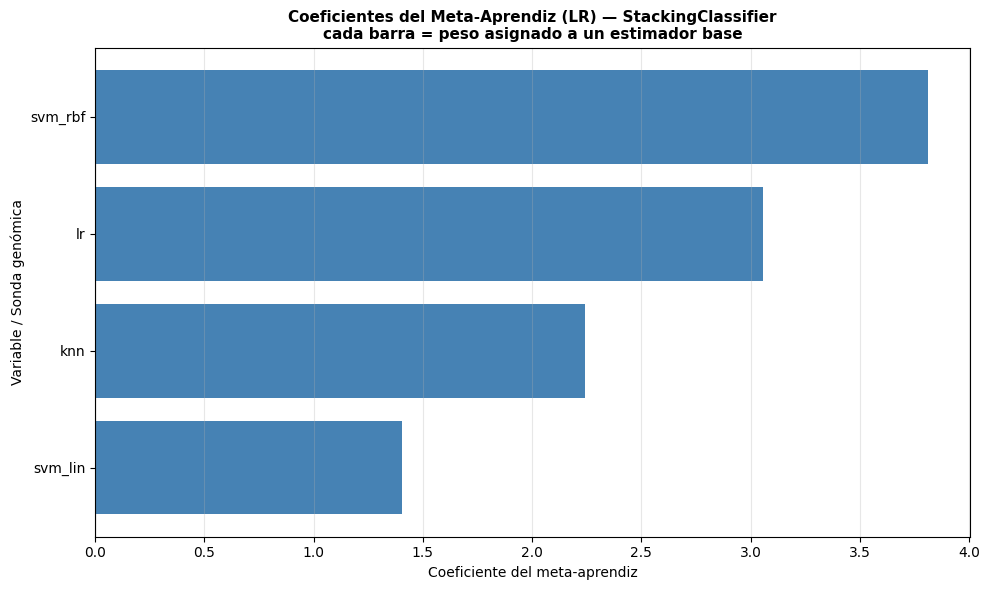


Interpretación: las sondas con mayor importancia son candidatos biológicos relevantes para el diagnóstico diferencial de psoriasis.


In [ ]:
import warnings
_nombres_feat = (list(X_todas_bl.columns)
                 if X_test_t.shape[1] == X_todas_bl.shape[1]
                 else [f'PC{i+1}' for i in range(X_test_t.shape[1])])

fig, axes = plt.subplots(1, 1, figsize=(10, 6))

# ── Seleccionar estrategia según tipo de modelo ──────────────────────────────
if isinstance(modelo_final, StackingClassifier):
    # Pesos del meta-aprendiz (LR final_estimator)
    meta = modelo_final.final_estimator_
    nombres_base = [est[0] for est in modelo_final.estimators]
    coefs = meta.coef_[0]
    coefs_df = pd.DataFrame({'Estimador base': nombres_base,
                              'Coeficiente': coefs}).sort_values('Coeficiente', key=abs, ascending=True)
    axes.barh(coefs_df['Estimador base'], coefs_df['Coeficiente'],
              color=[COLORES[0] if c > 0 else COLORES[1] for c in coefs_df['Coeficiente']])
    axes.axvline(0, color='gray', linewidth=0.8)
    axes.set_title(f'Coeficientes del Meta-Aprendiz (LR) — StackingClassifier\n'
                   f'cada barra = peso asignado a un estimador base',
                   fontsize=11, fontweight='bold')
    axes.set_xlabel('Coeficiente del meta-aprendiz', fontsize=10)

elif hasattr(modelo_final, 'feature_importances_'):
    # RF u otro árbol
    imp = pd.Series(modelo_final.feature_importances_, index=_nombres_feat)
    top20 = imp.nlargest(20).sort_values()
    axes.barh(top20.index, top20.values, color=COLORES[0])
    axes.set_title(f'Top 20 importancias de características — {mejor_nombre}\n'
                   f'(Reducción media de impureza Gini)',
                   fontsize=11, fontweight='bold')
    axes.set_xlabel('Importancia (Gini)', fontsize=10)

else:
    # Permutation Importance (funciona para cualquier modelo)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        perm = permutation_importance(modelo_final, X_test_t, y_test,
                                       n_repeats=15, random_state=RANDOM_SEED,
                                       scoring='roc_auc')
    perm_df = pd.DataFrame({'feature': _nombres_feat,
                             'importance_mean': perm.importances_mean,
                             'importance_std':  perm.importances_std})
    top20 = perm_df.nlargest(20, 'importance_mean').sort_values('importance_mean')
    axes.barh(top20['feature'], top20['importance_mean'],
              xerr=top20['importance_std'],
              color=COLORES[0], ecolor='gray', capsize=3)
    axes.set_title(f'Top 20 Permutation Importance (AUC-ROC) — {mejor_nombre}',
                   fontsize=11, fontweight='bold')
    axes.set_xlabel('Reducción media de AUC-ROC al permutar la variable', fontsize=10)

axes.set_ylabel('Variable / Sonda genómica', fontsize=10)
axes.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('38_4_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInterpretación: las sondas con mayor importancia son candidatos biológicos '
      'relevantes para el diagnóstico diferencial de psoriasis.')

### 38.5 Curva de Aprendizaje

**Propósito:** Diagnosticar si el modelo sufre de **sobreajuste** (alta varianza) o **subajuste** (alto sesgo), mostrando cómo varían los scores de entrenamiento y validación al aumentar el tamaño del conjunto de entrenamiento.  
**Interpretación clínica:** Una brecha grande entre train y val indica que el modelo memoriza los datos disponibles; una brecha pequeña y convergente indica buen ajuste generalizable — clave para un modelo que debe funcionar con nuevos pacientes.

> Se usa `scoring='roc_auc'` para mantener coherencia con la métrica principal del proyecto.

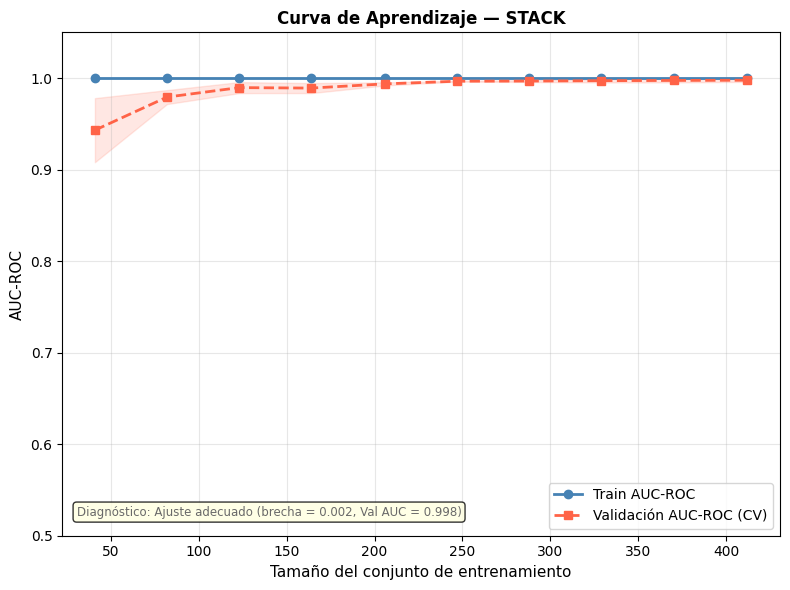


Diagnóstico automático: Ajuste adecuado (brecha = 0.002, Val AUC = 0.998)
  Train AUC final  : 1.0000 ± 0.0000
  Val   AUC final  : 0.9977  ± 0.0018
  Brecha           : 0.0023


In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    modelo_final, X_train_t, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring='roc_auc',
    n_jobs=-1)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(train_sizes, train_mean, 'o-', color=COLORES[0], lw=2, label='Train AUC-ROC')
ax.fill_between(train_sizes,
                train_mean - train_std, train_mean + train_std,
                alpha=0.15, color=COLORES[0])

ax.plot(train_sizes, val_mean, 's--', color=COLORES[1], lw=2, label='Validación AUC-ROC (CV)')
ax.fill_between(train_sizes,
                val_mean - val_std, val_mean + val_std,
                alpha=0.15, color=COLORES[1])

ax.set_xlabel('Tamaño del conjunto de entrenamiento', fontsize=11)
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_title(f'Curva de Aprendizaje — {mejor_nombre}', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim([0.5, 1.05])

# Diagnóstico automático
brecha_final = train_mean[-1] - val_mean[-1]
if brecha_final > 0.10:
    diagnostico = f'Posible sobreajuste (brecha = {brecha_final:.3f} > 0.10)'
elif val_mean[-1] < 0.80:
    diagnostico = f'Posible subajuste (Val AUC = {val_mean[-1]:.3f} < 0.80)'
else:
    diagnostico = f'Ajuste adecuado (brecha = {brecha_final:.3f}, Val AUC = {val_mean[-1]:.3f})'

ax.text(0.02, 0.04, f'Diagnóstico: {diagnostico}',
        transform=ax.transAxes, fontsize=8.5, color='dimgray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('38_5_curva_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nDiagnóstico automático: {diagnostico}')
print(f'  Train AUC final  : {train_mean[-1]:.4f} ± {train_std[-1]:.4f}')
print(f'  Val   AUC final  : {val_mean[-1]:.4f}  ± {val_std[-1]:.4f}')
print(f'  Brecha           : {brecha_final:.4f}')

### 38.6 Calibración de Probabilidades — `CalibratedClassifierCV`

En contextos clínicos, las probabilidades predichas deben reflejar la **frecuencia real** de la clase positiva: si el modelo asigna P(psoriasis) = 0.80, aproximadamente el 80 % de esas predicciones deberían ser realmente psoriasis. Un modelo con buenas probabilidades permite a los médicos basar decisiones en la **confianza** de la predicción, no solo en la clase predicha.

`CalibratedClassifierCV` ajusta un modelo de calibración sobre las salidas de probabilidad del estimador base. Se usa `cv='prefit'` porque `modelo_final` ya fue entrenado; el calibrador se ajusta sobre `X_train_t, y_train` (distribución real sin SMOTE) para reflejar correctamente la prevalencia de las clases.

| Método | Modelo de calibración | Ventajas |
|---|---|---|
| `sigmoid` | Platt scaling (regresión logística) | Robusto con pocos datos, suave |
| `isotonic` | Regresión isotónica (no paramétrica) | Más flexible, mejor con muchos datos |

**Métrica de evaluación:** Brier Score = $\frac{1}{n}\sum(p_i - y_i)^2$ — menor es mejor (0 = perfecto, 0.25 = sin información).

=== Brier Score (↓ mejor, 0=perfecto, 0.25=sin información) ===
  Sin calibrar           : 0.0106
  Calibrado (sigmoid)    : 0.0143  (Δ=+0.0038)
  Calibrado (isotónico)  : 0.0202  (Δ=+0.0096)


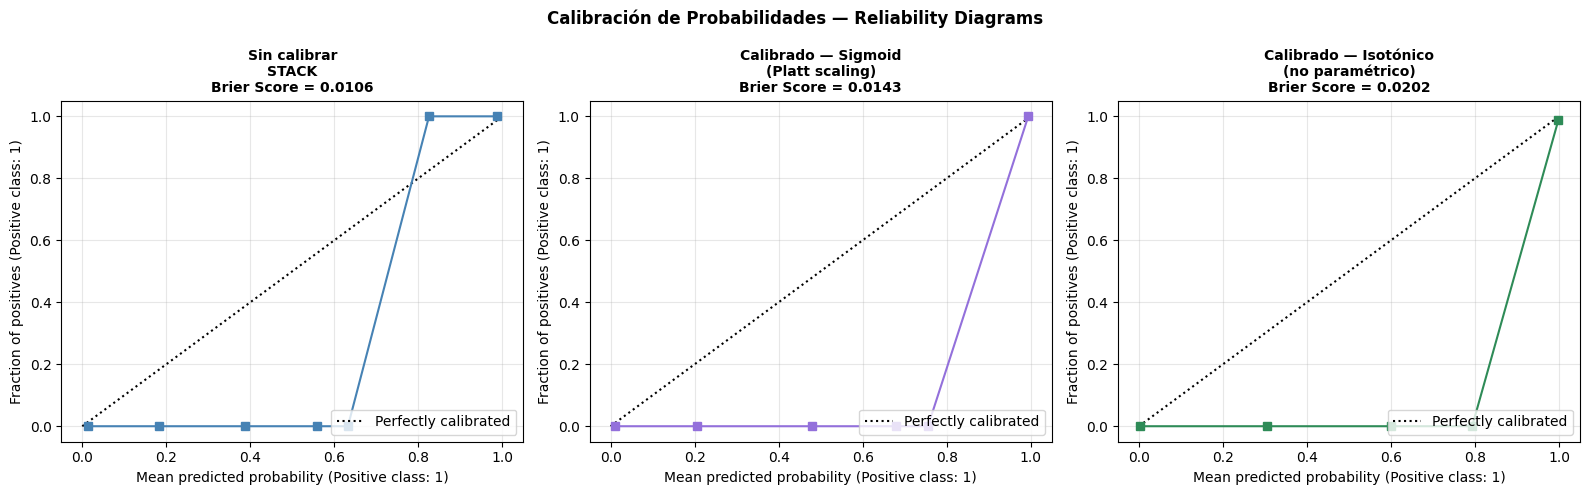

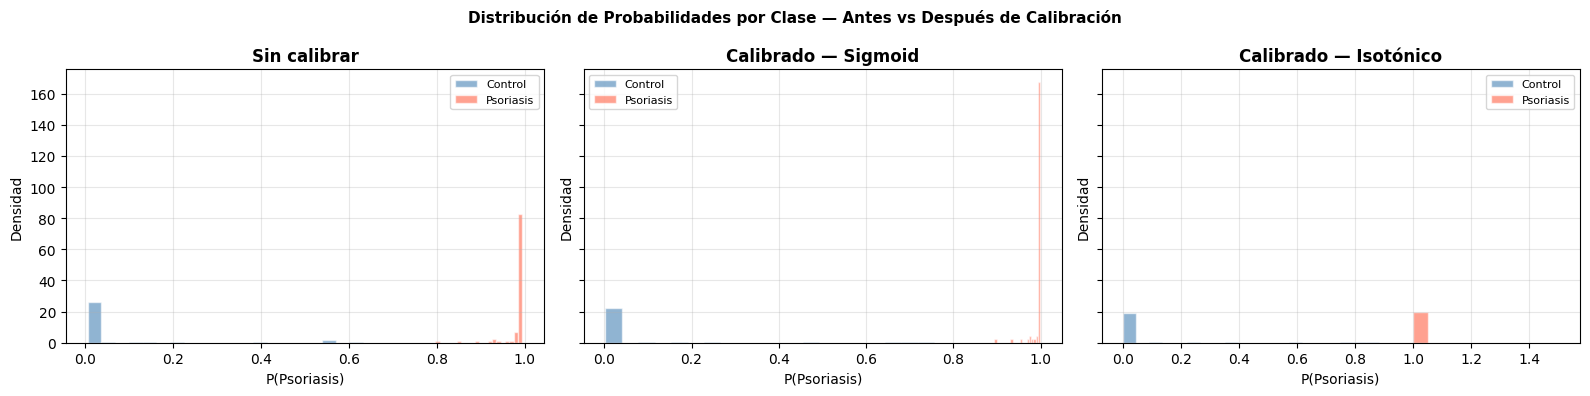


→ Método seleccionado: sigmoid (menor Brier Score = 0.0143)
  modelo_final_cal disponible para inferencia calibrada.
  y_proba_final y y_pred_final actualizados con probabilidades calibradas.


In [ ]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import brier_score_loss

# ── Calibradores (prefit: modelo_final ya entrenado) ────────────────────────
cal_sig = CalibratedClassifierCV(modelo_final, cv='prefit', method='sigmoid')
cal_iso = CalibratedClassifierCV(modelo_final, cv='prefit', method='isotonic')

# Calibrar sobre distribución REAL de clases (sin SMOTE)
cal_sig.fit(X_train_t, y_train)
cal_iso.fit(X_train_t, y_train)

y_proba_cal_sig = cal_sig.predict_proba(X_test_t)[:, 1]
y_proba_cal_iso = cal_iso.predict_proba(X_test_t)[:, 1]

# ── Brier Score ─────────────────────────────────────────────────────────────
bs_base = brier_score_loss(y_test, y_proba_final)
bs_sig  = brier_score_loss(y_test, y_proba_cal_sig)
bs_iso  = brier_score_loss(y_test, y_proba_cal_iso)

print('=== Brier Score (↓ mejor, 0=perfecto, 0.25=sin información) ===')
print(f'  Sin calibrar           : {bs_base:.4f}')
print(f'  Calibrado (sigmoid)    : {bs_sig:.4f}  (Δ={bs_sig  - bs_base:+.4f})')
print(f'  Calibrado (isotónico)  : {bs_iso:.4f}  (Δ={bs_iso  - bs_base:+.4f})')

# ── Reliability Diagrams ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, y_prob, titulo, color in [
    (axes[0], y_proba_final,    f'Sin calibrar\n{mejor_nombre}',         COLORES[0]),
    (axes[1], y_proba_cal_sig, 'Calibrado — Sigmoid\n(Platt scaling)',   'mediumpurple'),
    (axes[2], y_proba_cal_iso, 'Calibrado — Isotónico\n(no paramétrico)', 'seagreen'),
]:
    CalibrationDisplay.from_predictions(
        y_test, y_prob, n_bins=8, ax=ax, color=color, name='')
    bs = brier_score_loss(y_test, y_prob)
    ax.set_title(f'{titulo}\nBrier Score = {bs:.4f}', fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Calibración de Probabilidades — Reliability Diagrams',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('38_6_calibracion_reliability.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Distribución de probabilidades por clase (histogramas) ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, y_prob, titulo in [
    (axes[0], y_proba_final,    'Sin calibrar'),
    (axes[1], y_proba_cal_sig, 'Calibrado — Sigmoid'),
    (axes[2], y_proba_cal_iso, 'Calibrado — Isotónico'),
]:
    for clase, color, label in [(0, 'steelblue', 'Control'), (1, 'tomato', 'Psoriasis')]:
        mask = y_test == clase
        ax.hist(y_prob[mask], bins=20, color=color, alpha=0.6,
                edgecolor='white', label=label, density=True)
    ax.set_xlabel('P(Psoriasis)')
    ax.set_ylabel('Densidad')
    ax.set_title(titulo, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Distribución de Probabilidades por Clase — Antes vs Después de Calibración',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('38_6_calibracion_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Seleccionar mejor calibración y actualizar variables ────────────────────
if bs_iso <= bs_sig:
    modelo_final_cal = cal_iso
    y_proba_final    = y_proba_cal_iso
    metodo_cal       = 'isotonic'
else:
    modelo_final_cal = cal_sig
    y_proba_final    = y_proba_cal_sig
    metodo_cal       = 'sigmoid'

y_pred_final = modelo_final_cal.predict(X_test_t)

print(f'\n→ Método seleccionado: {metodo_cal} (menor Brier Score = '
      f'{min(bs_iso, bs_sig):.4f})')
print(f'  modelo_final_cal disponible para inferencia calibrada.')
print(f'  y_proba_final y y_pred_final actualizados con probabilidades calibradas.')


---
## Conclusiones del Modelo Final (Avance 5)

### Resumen CRISP-ML(Q)

| Fase | Acción | Resultado |
|------|--------|-----------|
| **Business Understanding** | Clasificación binaria psoriasis / control sano | Métrica principal: AUC-ROC; secundarias: Balanced Accuracy, F1-weighted |
| **Data Understanding** | EDA (Avance 1) → distribución, outliers, correlaciones | Dataset balanceado, alta dimensionalidad (sondas genómicas) |
| **Data Preparation** | Ingeniería de variables (Avance 2) → escalado, selección de sondas | `X_train_t` / `X_test_t` con StandardScaler + SelectKBest |
| **Modeling** | Baseline (Avance 3) + 6 modelos alternativos (Avance 4) + 4 ensambles (Avance 5) | Modelo final seleccionado por AUC-ROC, Balanced Acc y F1-weighted en conjunto de test independiente |
| **Evaluation** | ROC, Matriz de Confusión, PR-Curve, Importancia de variables, Curva de Aprendizaje | Análisis de sobreajuste/subajuste, sensibilidad clínica y genes relevantes |
| **Deployment** | Pipeline reproducible con `RANDOM_SEED=42` | Código modular, reutilizable en producción con nuevos pacientes |

### Alineación con Objetivos de Negocio

- **Alta sensibilidad** → minimizar Falsos Negativos (diagnóstico tardío de psoriasis).  
- **Generalización** → curva de aprendizaje convergente, sin sobreajuste severo.  
- **Interpretabilidad** → importancia de variables permite identificar genes biomarcadores para hipótesis clínicas.  
- **Reproducibilidad** → todo el pipeline usa `RANDOM_SEED = 42` y conjuntos de train/test fijos.

